# Fraud Detection — Full Exploratory Data Analysis
### CSV Tabular Data + Heterogeneous Graph Data

This notebook provides a comprehensive EDA covering:
- **Part 1:** Tabular analysis of the raw CSV dataset (50,000 transactions)
- **Part 2:** Structural and feature analysis of the processed heterogeneous graph

---

## Setup

In [1]:
# ── Install dependencies (Colab) ──────────────────────────────────────────
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

try:
    import torch_geometric
except ImportError:
    install('torch_geometric')

try:
    import networkx
except ImportError:
    install('networkx')

In [2]:
# ── Core imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import networkx as nx
import torch
import os

# ── Global plot style ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
})

# ── Palette constants ────────────────────────────────────────────────────
FRAUD_COLOR   = '#E74C3C'   # red
LEGIT_COLOR   = '#2ECC71'   # green
ACCENT_COLOR  = '#3498DB'   # blue
NEUTRAL_COLOR = '#95A5A6'   # grey
PALETTE       = [LEGIT_COLOR, FRAUD_COLOR]

# ── Path helper ──────────────────────────────────────────────────────────
BASE = os.path.join(os.path.dirname(os.getcwd()), '') if 'notebooks' not in os.getcwd() else '..'
DATA_CSV   = os.path.join(BASE, 'data', 'Fraud Detection Transactions Dataset.csv')
GRAPH_PT   = os.path.join(BASE, 'data', 'processed_graph.pt')

print('CSV path :', DATA_CSV)
print('Graph path:', GRAPH_PT)

CSV path : ..\data\Fraud Detection Transactions Dataset.csv
Graph path: ..\data\processed_graph.pt


---
# Part 1 — Tabular / CSV EDA

## 1.1 Load Data

In [3]:
df = pd.read_csv(DATA_CSV, parse_dates=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

# Derived temporal columns
df['Hour']      = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek   # 0=Mon
df['Month']     = df['Timestamp'].dt.month
df['Day']       = df['Timestamp'].dt.day

print(f'Shape : {df.shape}')
print(f'Fraud rate: {df.Fraud_Label.mean():.1%}  ({df.Fraud_Label.sum():,} fraud / {(~df.Fraud_Label.astype(bool)).sum():,} legit)')
df.head(3)

Shape : (50000, 25)
Fraud rate: 32.1%  (16,067 fraud / 33,933 legit)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label,Hour,DayOfWeek,Month,Day
0,TXN_2862,USER_6086,72.54,ATM Withdrawal,2023-01-01 00:01:00,60673.36,Mobile,New York,Travel,0,...,192,3527.88,OTP,0.7218,0,0,0,6,1,1
1,TXN_47895,USER_6749,78.68,Bank Transfer,2023-01-01 00:42:00,75204.02,Tablet,Mumbai,Travel,0,...,142,1003.16,OTP,0.3373,0,0,0,6,1,1
2,TXN_20029,USER_6468,63.97,POS,2023-01-01 00:46:00,44124.04,Tablet,Mumbai,Restaurants,0,...,116,2411.48,PIN,0.9262,0,1,0,6,1,1


## 1.2 Dataset Overview — Schema & Data Quality

In [4]:
# ── Data-type & missing-value summary table ───────────────────────────────
summary = pd.DataFrame({
    'dtype'  : df.dtypes,
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().mean() * 100).round(2),
    'unique' : df.nunique(),
    'min'    : df.min(numeric_only=False).astype(str),
    'max'    : df.max(numeric_only=False).astype(str),
})
summary.style.background_gradient(subset=['missing'], cmap='Reds')

,dtype,missing,missing_%,unique,min,max
Transaction_ID,object,0,0.000000,50000,TXN_0,TXN_9999
User_ID,object,0,0.000000,8963,USER_1000,USER_9998
Transaction_Amount,float64,0,0.000000,21763,0.0,1174.14
Transaction_Type,object,0,0.000000,4,ATM Withdrawal,POS
Timestamp,datetime64[ns],0,0.000000,47724,2023-01-01 00:01:00,2023-12-31 23:50:00
Account_Balance,float64,0,0.000000,49867,500.48,99998.31
Device_Type,object,0,0.000000,3,Laptop,Tablet
Location,object,0,0.000000,5,London,Tokyo
Merchant_Category,object,0,0.000000,5,Clothing,Travel
IP_Address_Flag,int64,0,0.000000,2,0,1


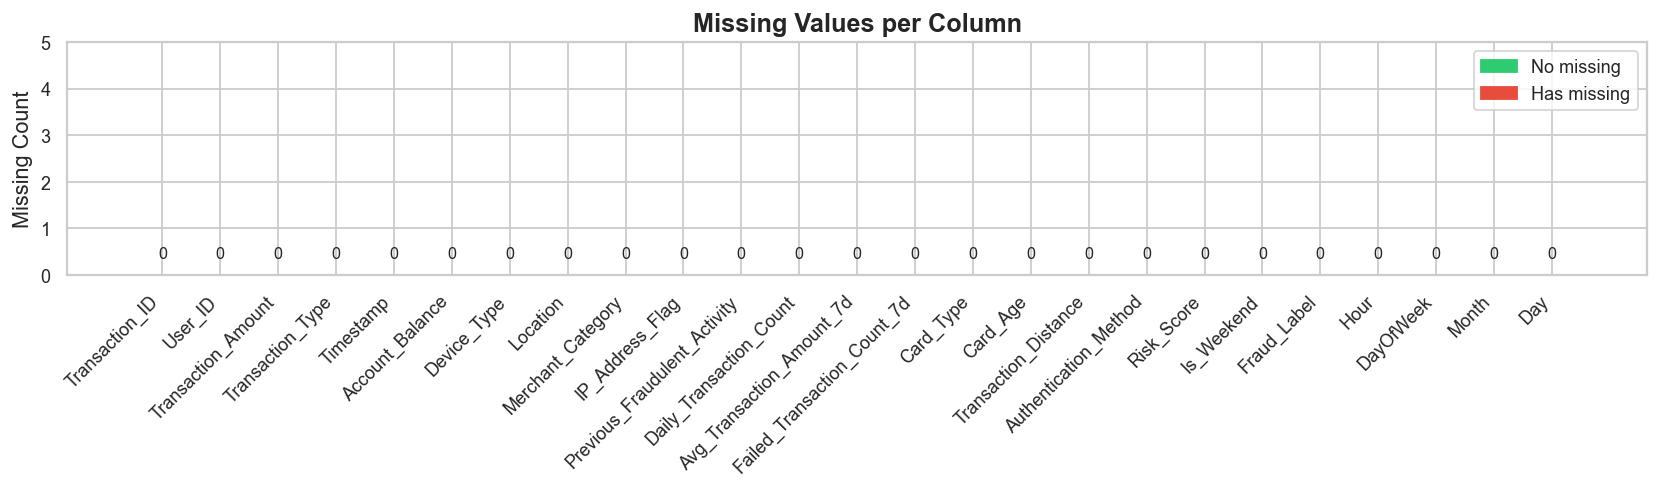

No missing values detected — dataset is complete.


In [5]:
# ── Missing-values bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
miss = df.isnull().sum().sort_values(ascending=False)
colors = [FRAUD_COLOR if v > 0 else LEGIT_COLOR for v in miss]
bars = ax.bar(miss.index, miss.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Missing Values per Column', fontweight='bold')
ax.set_ylabel('Missing Count')
ax.set_xticklabels(miss.index, rotation=45, ha='right')
# Annotate bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, max(miss.values) + 5 if max(miss.values) > 0 else 5)
legend_handles = [mpatches.Patch(color=LEGIT_COLOR, label='No missing'),
                  mpatches.Patch(color=FRAUD_COLOR, label='Has missing')]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.show()
print('No missing values detected — dataset is complete.')

## 1.3 Target Variable — Fraud Distribution

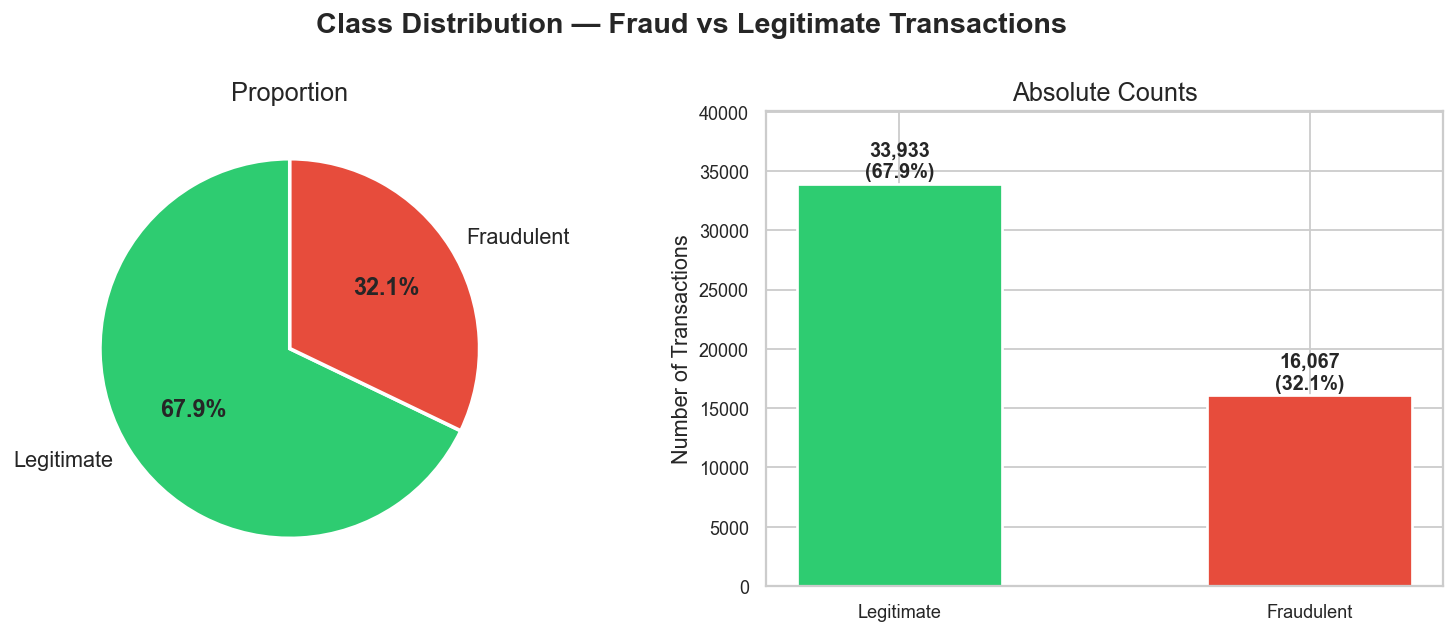

In [6]:
counts = df['Fraud_Label'].value_counts().sort_index()
labels = ['Legitimate', 'Fraudulent']
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Class Distribution — Fraud vs Legitimate Transactions', fontweight='bold')

# Pie
wedges, texts, autotexts = axes[0].pie(
    counts, labels=labels, autopct='%1.1f%%',
    colors=PALETTE, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12})
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
axes[0].set_title('Proportion')

# Bar
bars = axes[1].bar(labels, counts.values, color=PALETTE, width=0.5,
                   edgecolor='white', linewidth=1.5)
for bar, count, pct in zip(bars, counts.values, pcts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{count:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_title('Absolute Counts')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_ylim(0, max(counts.values) * 1.18)

plt.tight_layout()
plt.show()

## 1.4 Numerical Feature Distributions

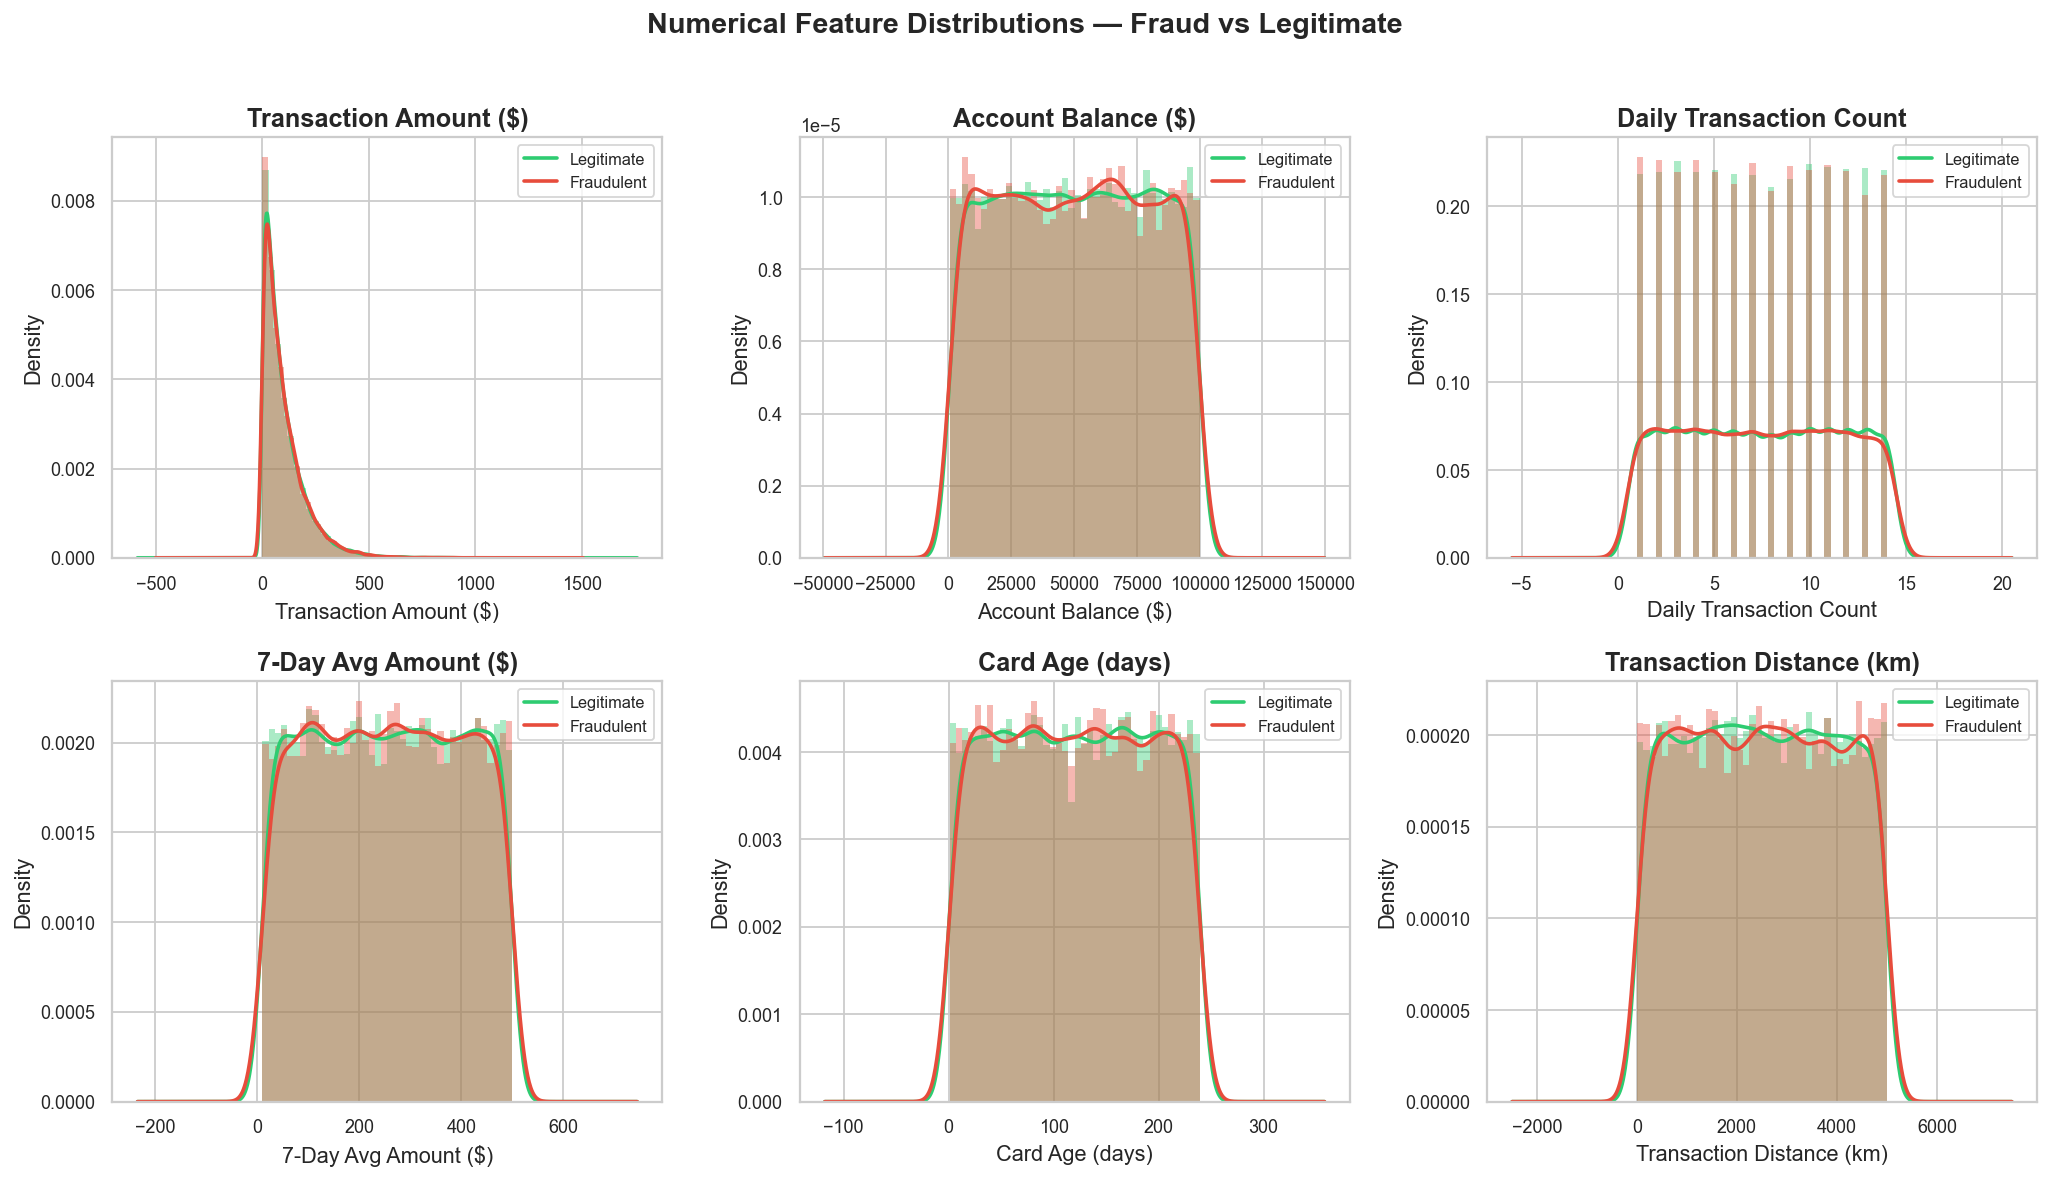

In [7]:
NUM_COLS = [
    'Transaction_Amount', 'Account_Balance',
    'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
    'Card_Age', 'Transaction_Distance'
]
COL_LABELS = [
    'Transaction Amount ($)', 'Account Balance ($)',
    'Daily Transaction Count', '7-Day Avg Amount ($)',
    'Card Age (days)', 'Transaction Distance (km)'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Numerical Feature Distributions — Fraud vs Legitimate', fontweight='bold', y=1.01)

for ax, col, label in zip(axes.flat, NUM_COLS, COL_LABELS):
    for fraud_val, color, lname in [(0, LEGIT_COLOR, 'Legitimate'), (1, FRAUD_COLOR, 'Fraudulent')]:
        data = df.loc[df.Fraud_Label == fraud_val, col].dropna()
        ax.hist(data, bins=40, density=True, alpha=0.4, color=color, edgecolor='none')
        data.plot.kde(ax=ax, color=color, linewidth=2, label=lname)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 1.5 Numerical Features vs Fraud — Violin Plots

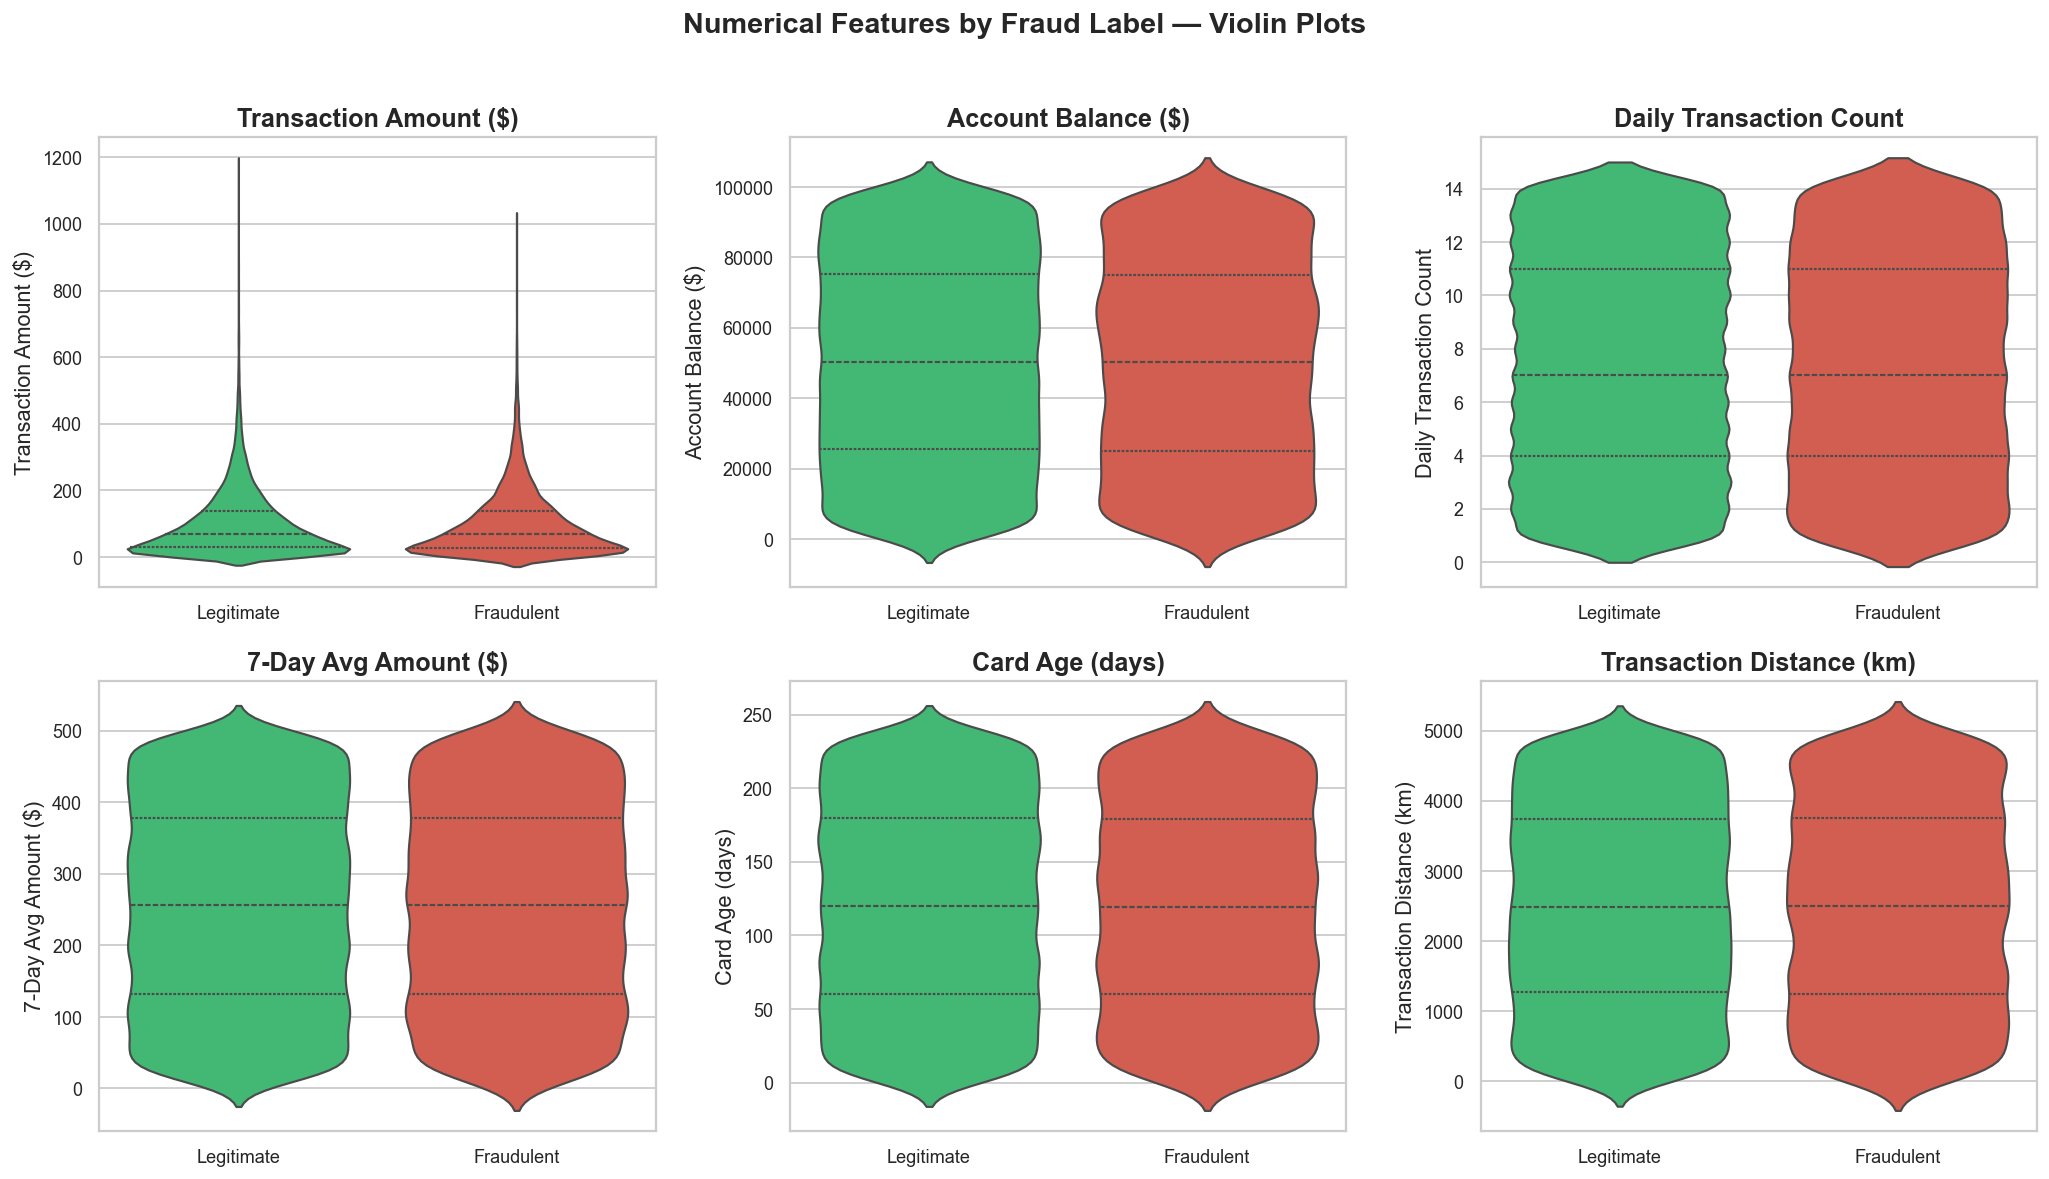

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Numerical Features by Fraud Label — Violin Plots', fontweight='bold', y=1.01)

plot_df = df[NUM_COLS + ['Fraud_Label']].copy()
plot_df['Class'] = plot_df['Fraud_Label'].map({0: 'Legitimate', 1: 'Fraudulent'})

for ax, col, label in zip(axes.flat, NUM_COLS, COL_LABELS):
    sns.violinplot(
        data=plot_df, x='Class', y=col, ax=ax,
        palette={'Legitimate': LEGIT_COLOR, 'Fraudulent': FRAUD_COLOR},
        inner='quartile', linewidth=1.2)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

## 1.6 Statistical Summary

In [9]:
stat_legit = df.loc[df.Fraud_Label==0, NUM_COLS].describe().T
stat_fraud = df.loc[df.Fraud_Label==1, NUM_COLS].describe().T

stat_legit.columns = [f'Legit_{c}' for c in stat_legit.columns]
stat_fraud.columns = [f'Fraud_{c}' for c in stat_fraud.columns]

combined = pd.concat([stat_legit[['Legit_mean','Legit_std','Legit_min','Legit_max']],
                      stat_fraud[['Fraud_mean','Fraud_std','Fraud_min','Fraud_max']]], axis=1)
combined.index = COL_LABELS
combined.round(2).style.background_gradient(subset=['Legit_mean','Fraud_mean'], cmap='RdYlGn_r')

,Legit_mean,Legit_std,Legit_min,Legit_max,Fraud_mean,Fraud_std,Fraud_min,Fraud_max
Transaction Amount ($),99.280000,98.460000,0.010000,1174.140000,99.680000,99.160000,0.000000,1005.320000
Account Balance ($),50356.470000,28734.000000,500.480000,99998.310000,50162.260000,28816.710000,503.940000,99997.790000
Daily Transaction Count,7.500000,4.040000,1.000000,14.000000,7.440000,4.040000,1.000000,14.000000
7-Day Avg Amount ($),255.200000,141.610000,10.010000,500.000000,255.420000,140.900000,10.000000,499.990000
Card Age (days),120.150000,69.020000,1.000000,239.000000,119.690000,68.920000,1.000000,239.000000
Transaction Distance (km),2499.280000,1438.550000,0.250000,4999.930000,2498.920000,1449.350000,0.560000,4999.910000


## 1.7 Correlation Analysis

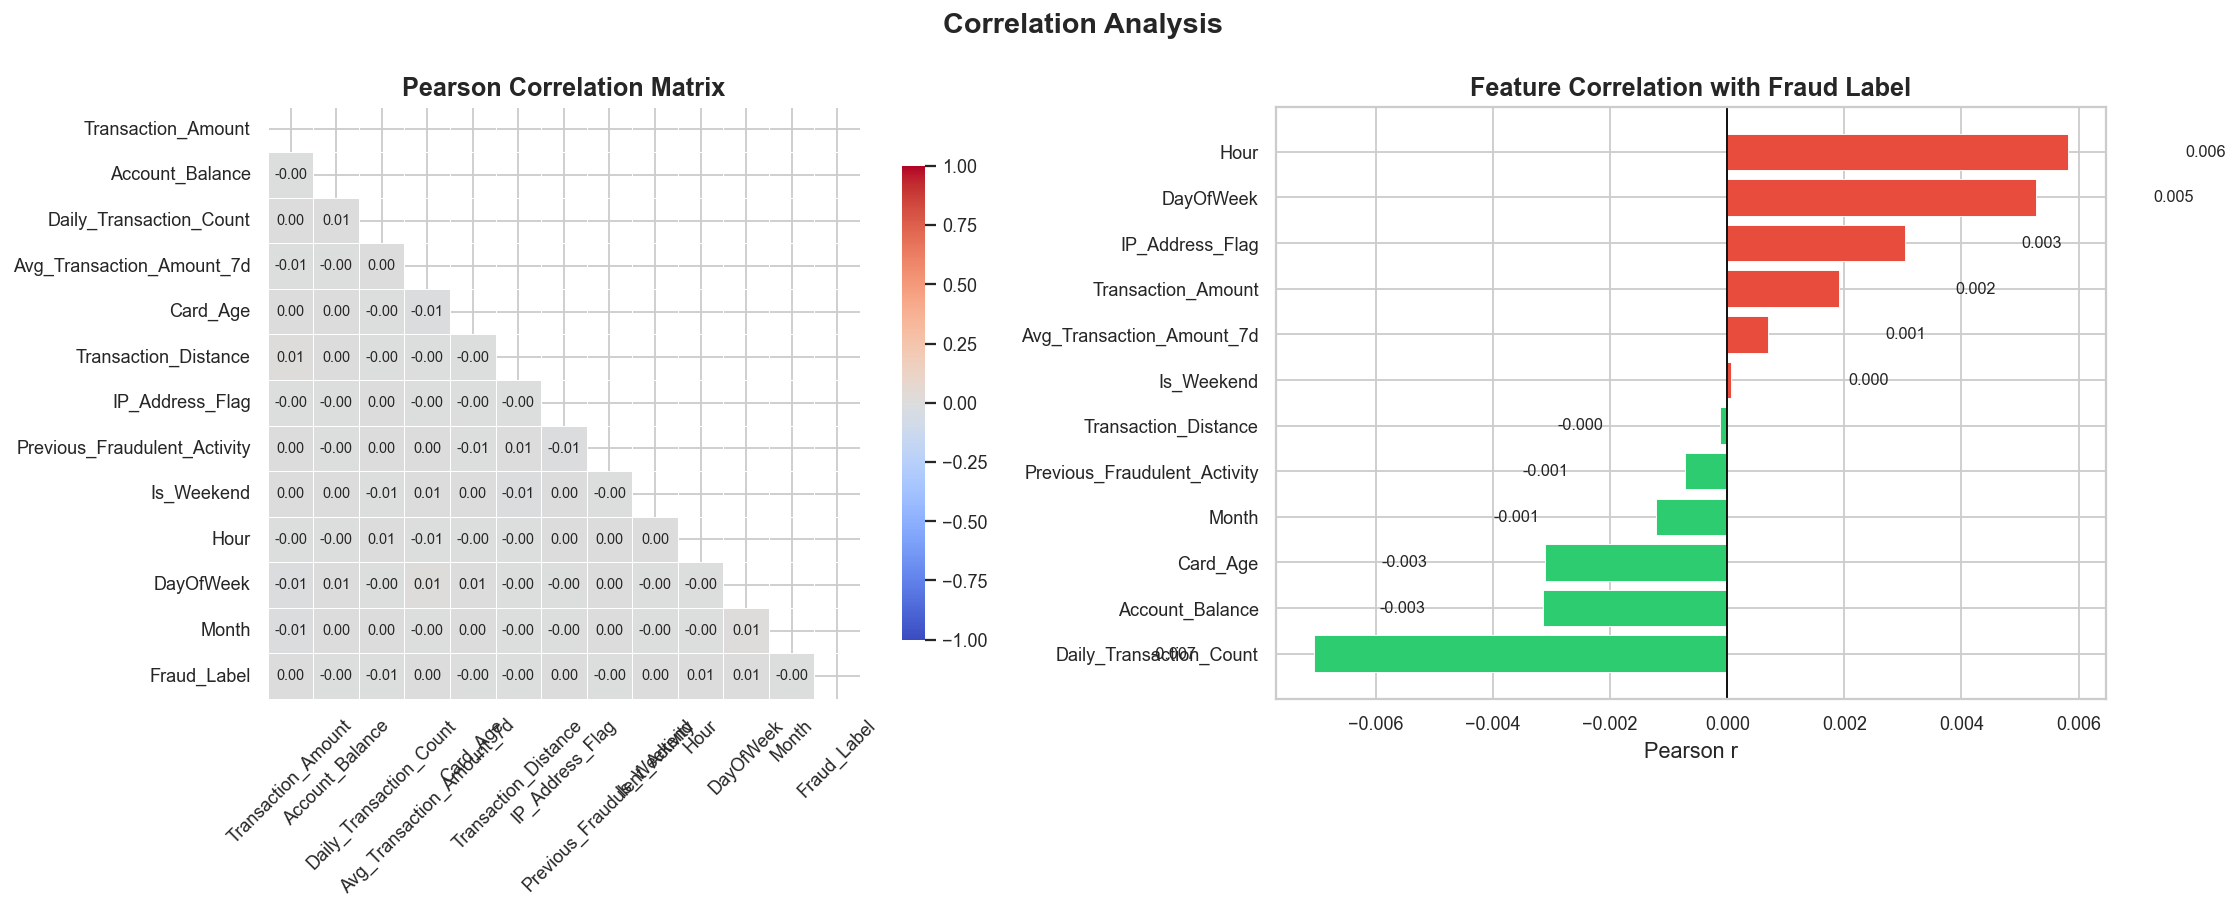

In [10]:
# ── Correlation heatmap ───────────────────────────────────────────────────
CORR_COLS = NUM_COLS + ['IP_Address_Flag', 'Previous_Fraudulent_Activity',
                        'Is_Weekend', 'Hour', 'DayOfWeek', 'Month', 'Fraud_Label']
corr = df[CORR_COLS].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Correlation Analysis', fontweight='bold')

# Full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[0], annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 8},
            square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Pearson Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Feature-fraud correlation bar chart
fraud_corr = corr['Fraud_Label'].drop('Fraud_Label').sort_values()
colors_bar = [FRAUD_COLOR if v > 0 else LEGIT_COLOR for v in fraud_corr]
axes[1].barh(fraud_corr.index, fraud_corr.values, color=colors_bar,
             edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Feature Correlation with Fraud Label', fontweight='bold')
axes[1].set_xlabel('Pearson r')
for i, v in enumerate(fraud_corr.values):
    axes[1].text(v + (0.002 if v >= 0 else -0.002), i,
                 f'{v:.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

## 1.8 Categorical Features — Fraud Rate Analysis

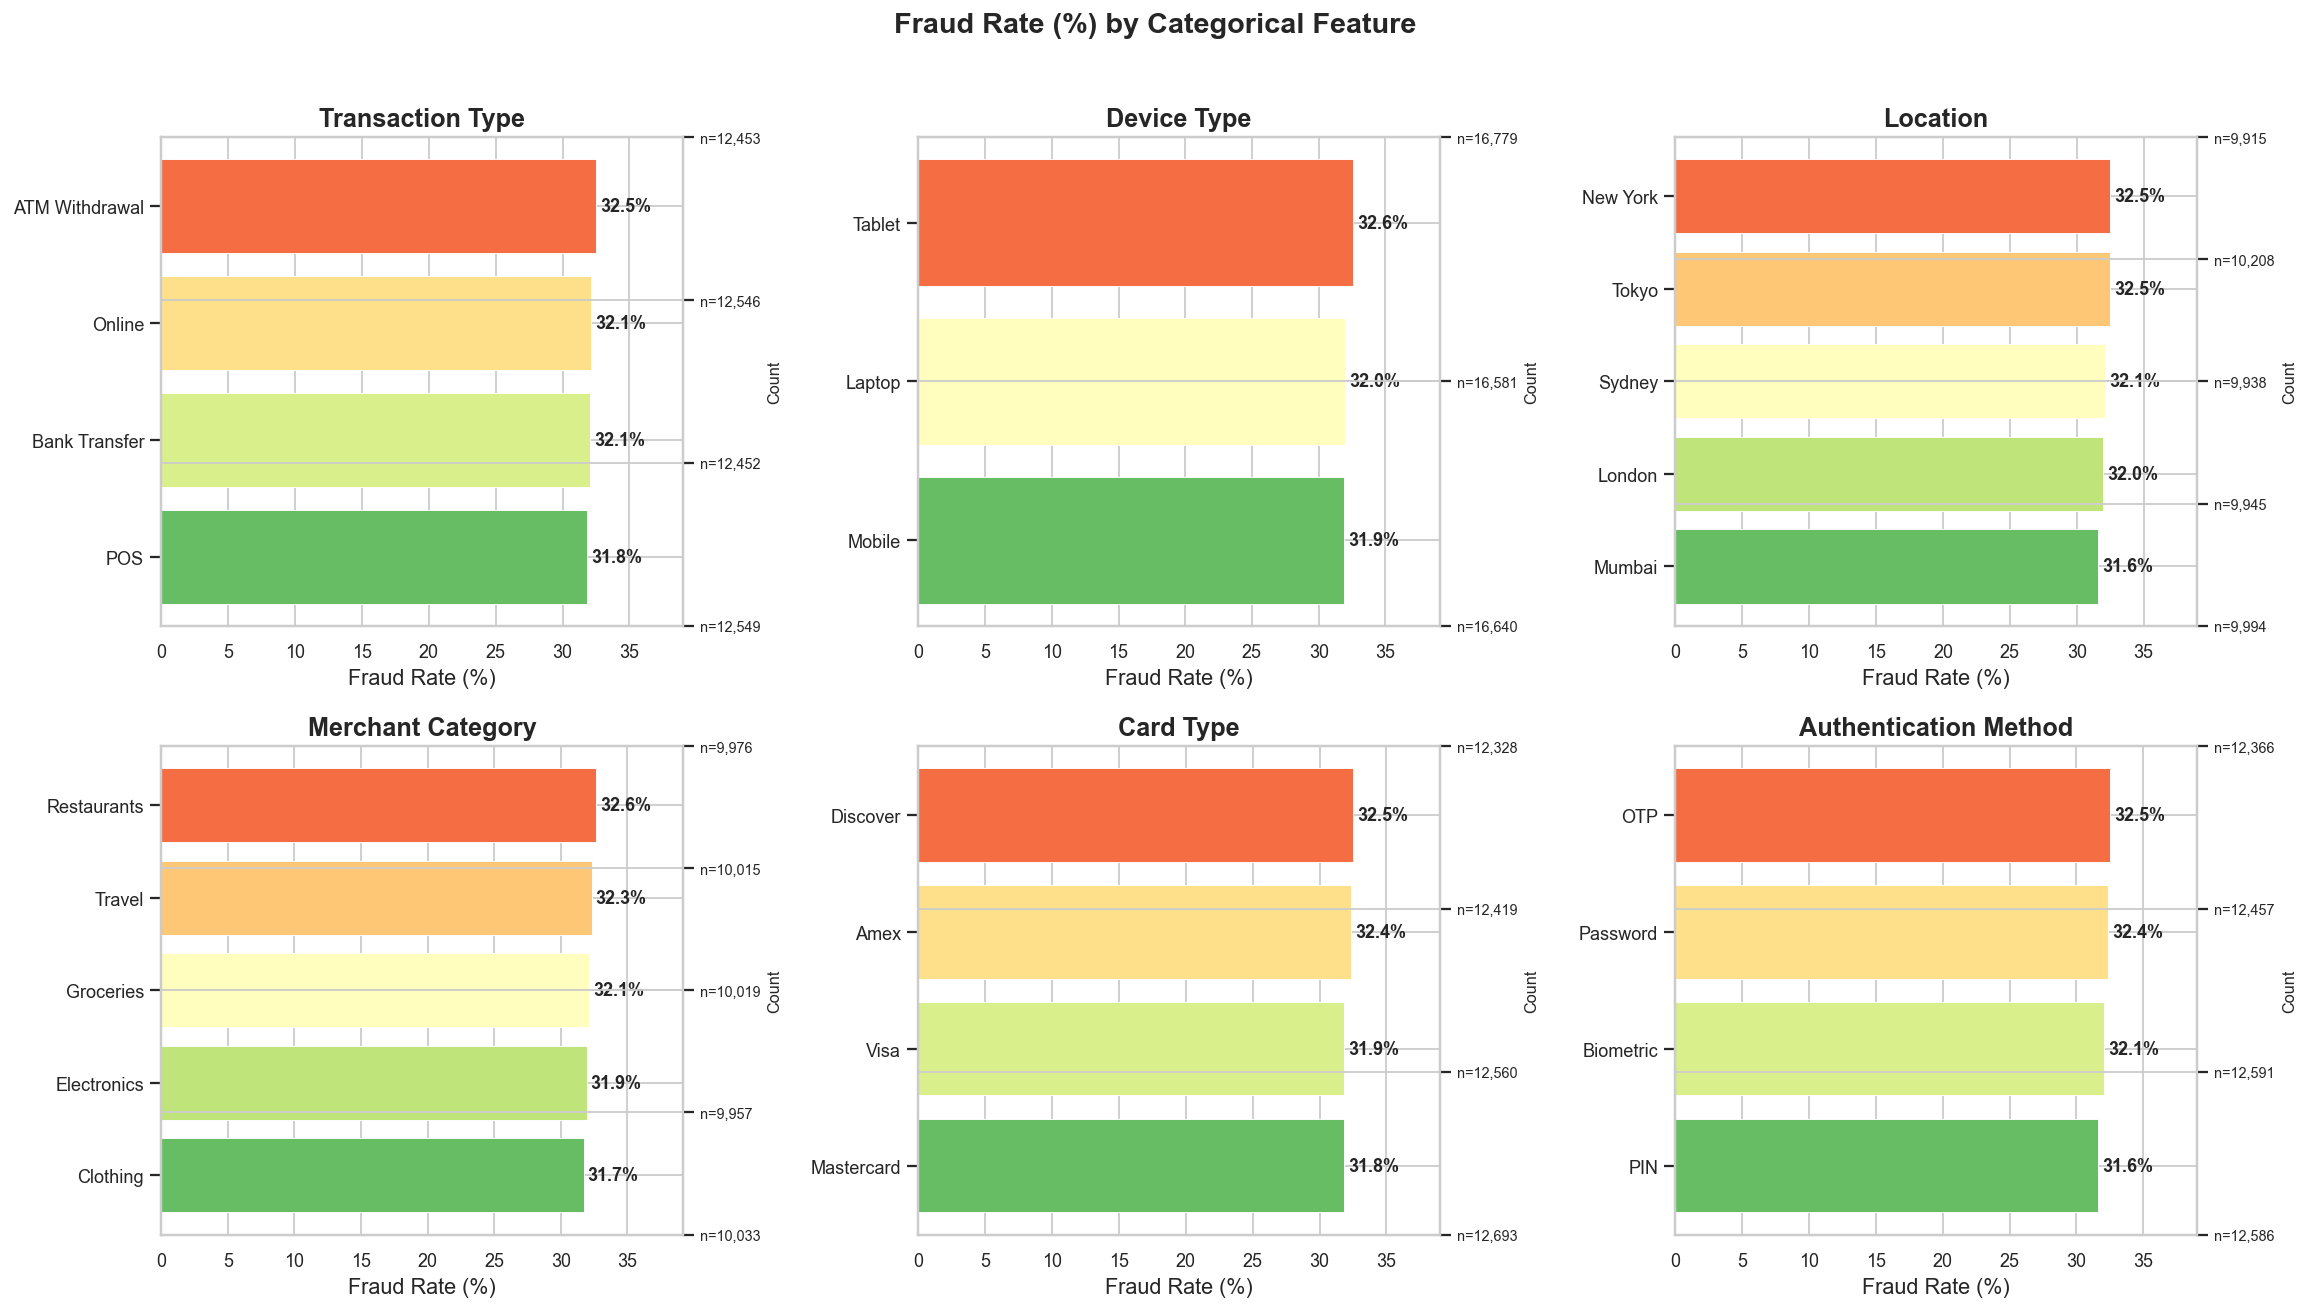

In [11]:
CAT_COLS = [
    ('Transaction_Type',     'Transaction Type'),
    ('Device_Type',          'Device Type'),
    ('Location',             'Location'),
    ('Merchant_Category',    'Merchant Category'),
    ('Card_Type',            'Card Type'),
    ('Authentication_Method','Authentication Method'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Fraud Rate (%) by Categorical Feature', fontweight='bold', y=1.01)

for ax, (col, title) in zip(axes.flat, CAT_COLS):
    fraud_rate = (df.groupby(col)['Fraud_Label']
                    .mean()
                    .mul(100)
                    .sort_values(ascending=True))
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(fraud_rate)))
    bars = ax.barh(fraud_rate.index, fraud_rate.values,
                   color=colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, fraud_rate.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', ha='left', fontsize=10, fontweight='bold')
    ax.set_xlim(0, fraud_rate.max() * 1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Fraud Rate (%)')
    # Volume annotation
    counts_cat = df[col].value_counts()
    ax2 = ax.twinx()
    ax2.set_yticks(range(len(fraud_rate)))
    ax2.set_yticklabels([f'n={counts_cat[c]:,}' for c in fraud_rate.index], fontsize=8)
    ax2.set_ylabel('Count', fontsize=9)

plt.tight_layout()
plt.show()

## 1.9 Binary Features vs Fraud

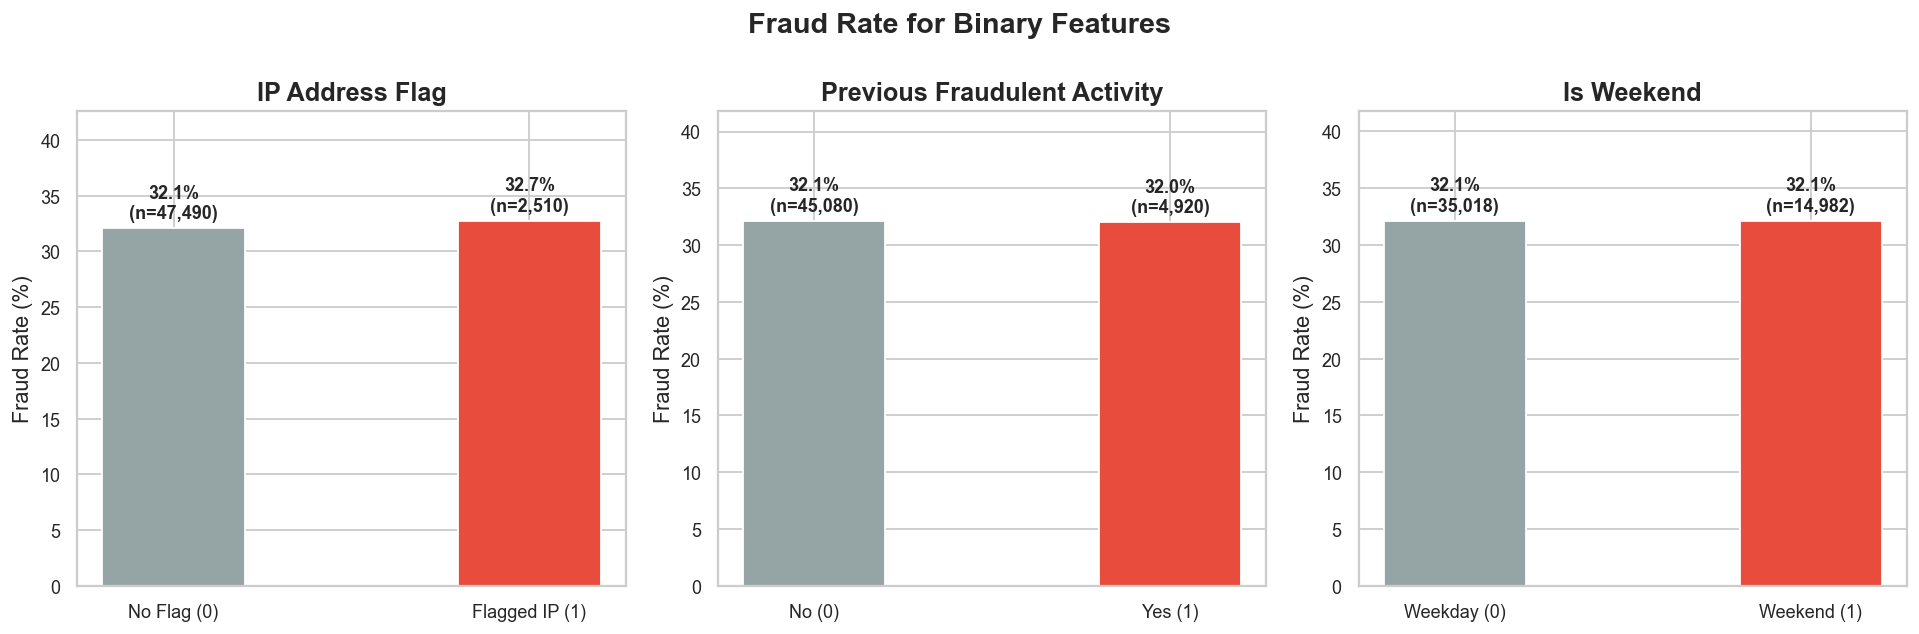

In [12]:
BIN_COLS = [
    ('IP_Address_Flag',              'IP Address Flag',           ['No Flag (0)', 'Flagged IP (1)']),
    ('Previous_Fraudulent_Activity', 'Previous Fraudulent Activity', ['No (0)', 'Yes (1)']),
    ('Is_Weekend',                   'Is Weekend',                ['Weekday (0)', 'Weekend (1)']),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Fraud Rate for Binary Features', fontweight='bold')

for ax, (col, title, xlabels) in zip(axes, BIN_COLS):
    rates = df.groupby(col)['Fraud_Label'].mean() * 100
    cnts  = df.groupby(col)['Fraud_Label'].count()
    bars = ax.bar(xlabels, rates.values,
                  color=[NEUTRAL_COLOR, FRAUD_COLOR], width=0.4,
                  edgecolor='white', linewidth=1)
    for bar, val, cnt in zip(bars, rates.values, cnts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}%\n(n={cnt:,})',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(rates.values) * 1.3)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

## 1.10 Temporal Analysis

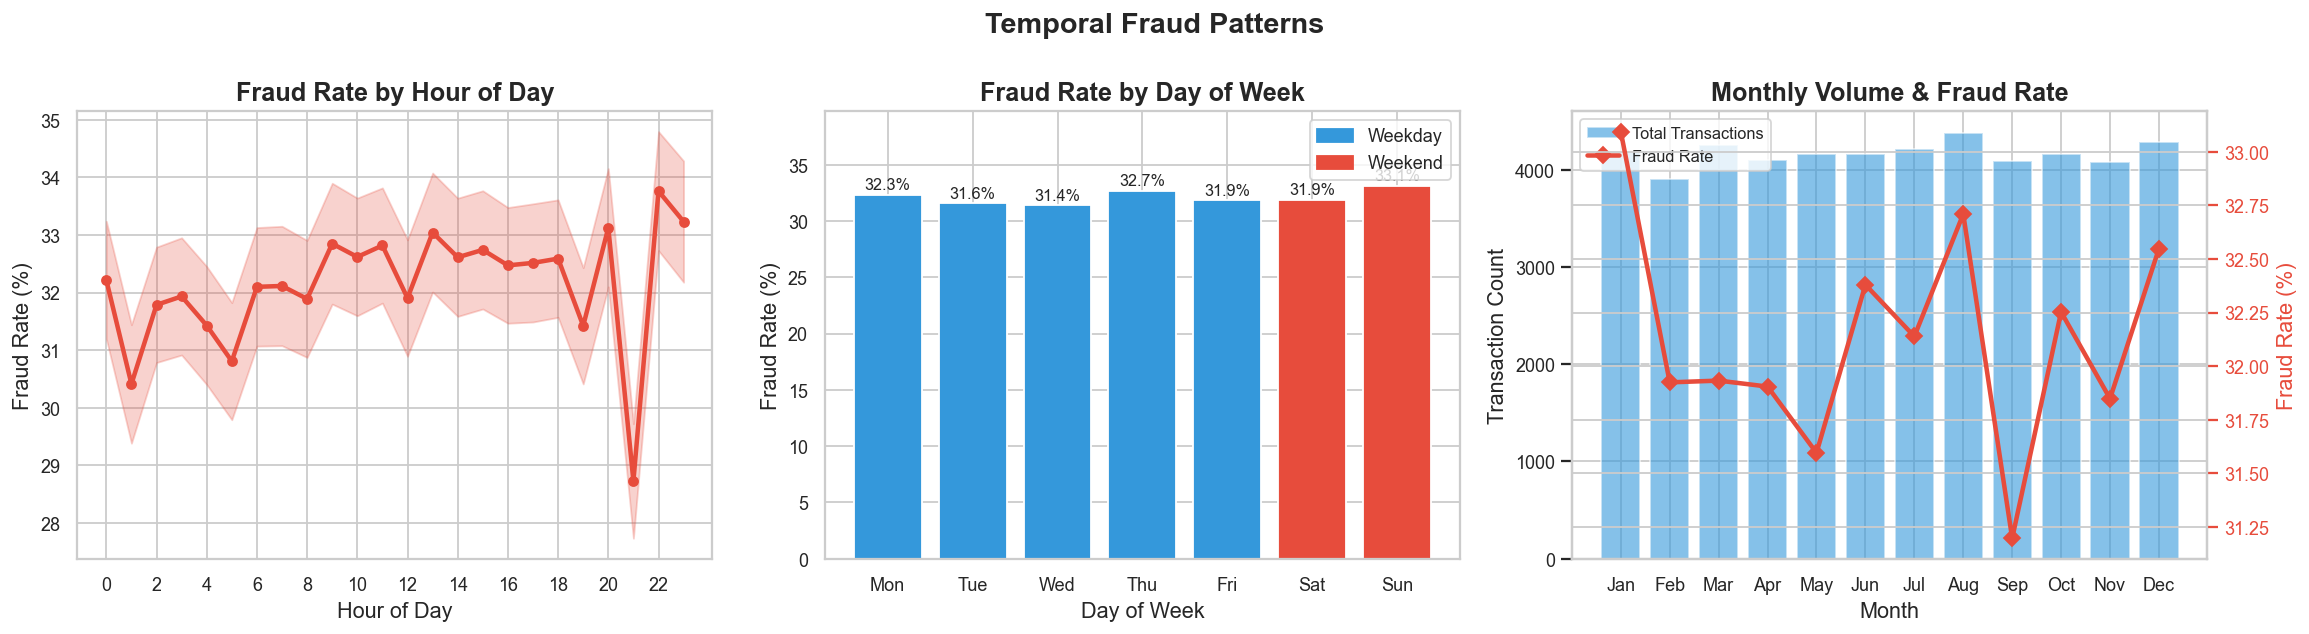

In [13]:
DAY_NAMES = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Temporal Fraud Patterns', fontweight='bold')

# 1. Fraud rate by Hour
hourly = df.groupby('Hour')['Fraud_Label'].agg(['mean','count'])
hourly['mean_pct'] = hourly['mean'] * 100
se = np.sqrt(hourly['mean'] * (1 - hourly['mean']) / hourly['count']) * 100
axes[0].fill_between(hourly.index,
                      hourly['mean_pct'] - se,
                      hourly['mean_pct'] + se,
                      alpha=0.25, color=FRAUD_COLOR)
axes[0].plot(hourly.index, hourly['mean_pct'],
             color=FRAUD_COLOR, linewidth=2.5, marker='o', markersize=5)
axes[0].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xticks(range(0, 24, 2))

# 2. Fraud rate by Day of Week
daily = df.groupby('DayOfWeek')['Fraud_Label'].mean() * 100
colors_dow = [FRAUD_COLOR if i >= 5 else ACCENT_COLOR for i in daily.index]
axes[1].bar(DAY_NAMES, daily.values, color=colors_dow,
            edgecolor='white', linewidth=1)
for i, v in enumerate(daily.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Fraud Rate by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_ylim(0, max(daily.values) * 1.2)
weekend_patch = mpatches.Patch(color=FRAUD_COLOR, label='Weekend')
weekday_patch = mpatches.Patch(color=ACCENT_COLOR, label='Weekday')
axes[1].legend(handles=[weekday_patch, weekend_patch])

# 3. Monthly volume + fraud rate (dual axis)
monthly_vol   = df.groupby('Month').size()
monthly_fraud = df.groupby('Month')['Fraud_Label'].mean() * 100
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x = monthly_vol.index
axes[2].bar([month_names[m-1] for m in x], monthly_vol.values,
            color=ACCENT_COLOR, alpha=0.6, label='Total Transactions')
ax3b = axes[2].twinx()
ax3b.plot([month_names[m-1] for m in x], monthly_fraud.values,
          color=FRAUD_COLOR, linewidth=2.5, marker='D', markersize=6, label='Fraud Rate')
axes[2].set_title('Monthly Volume & Fraud Rate', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Transaction Count')
ax3b.set_ylabel('Fraud Rate (%)', color=FRAUD_COLOR)
ax3b.tick_params(axis='y', colors=FRAUD_COLOR)
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.show()

## 1.11 Feature Interaction Analysis

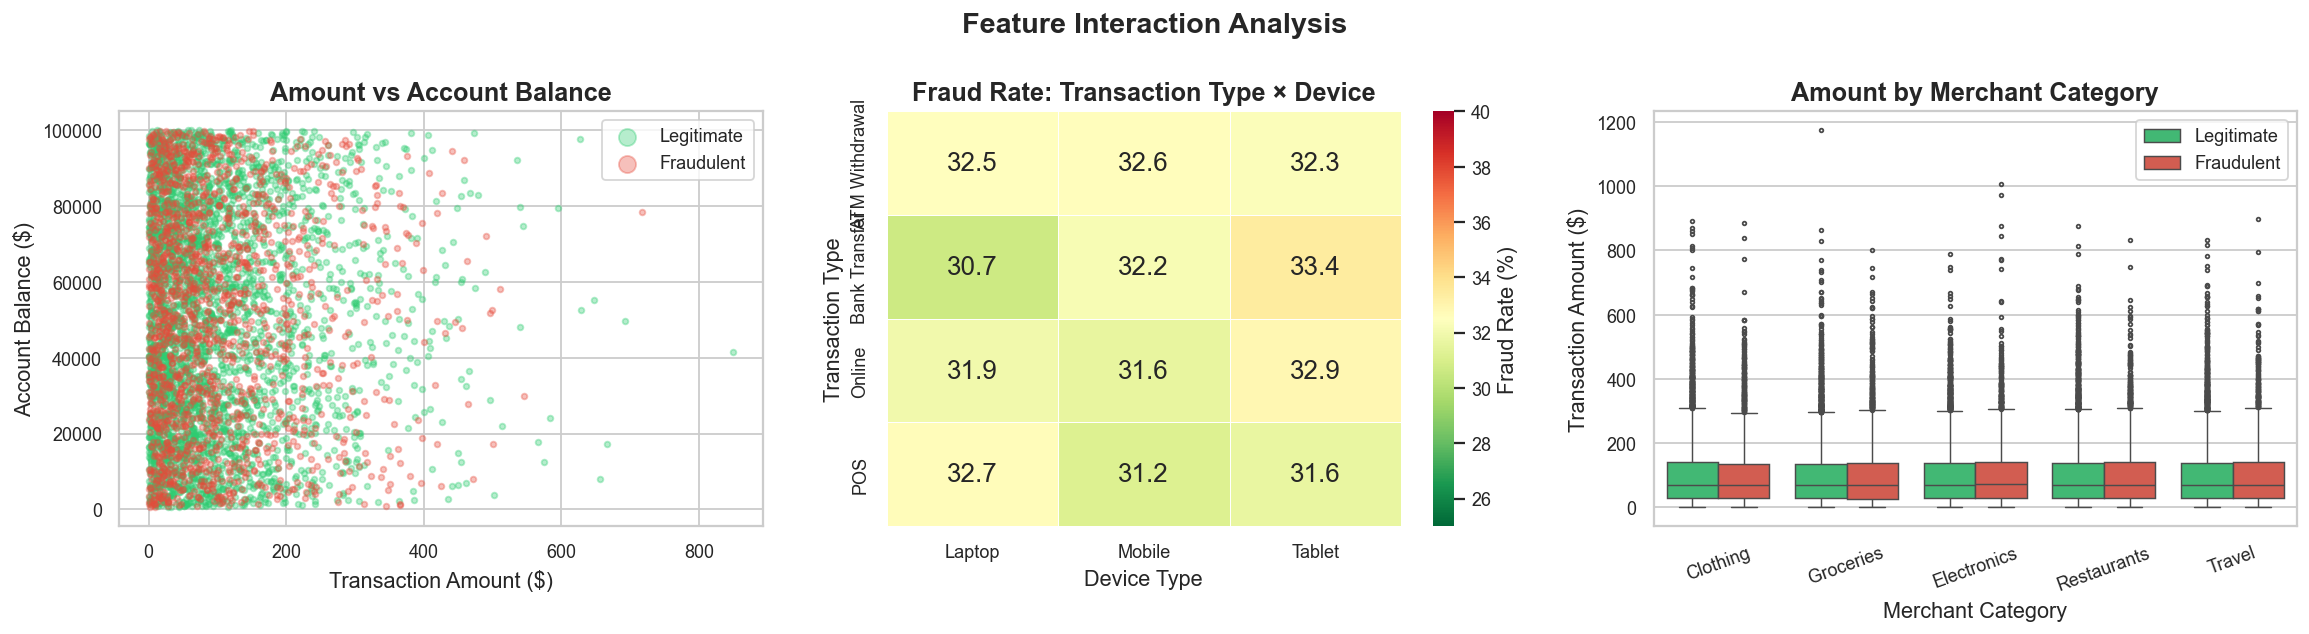

In [14]:
# ── Amount vs Balance scatter (5k sample) ────────────────────────────────
sample = df.sample(5000, random_state=42).copy()
sample['Class'] = sample['Fraud_Label'].map({0: 'Legitimate', 1: 'Fraudulent'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Feature Interaction Analysis', fontweight='bold')

# Scatter: Amount vs Balance
for fraud_val, color, lname in [(0, LEGIT_COLOR, 'Legitimate'), (1, FRAUD_COLOR, 'Fraudulent')]:
    s = sample[sample.Fraud_Label == fraud_val]
    axes[0].scatter(s['Transaction_Amount'], s['Account_Balance'],
                    c=color, alpha=0.35, s=10, label=lname)
axes[0].set_title('Amount vs Account Balance', fontweight='bold')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Account Balance ($)')
axes[0].legend(markerscale=3)

# Heatmap: Transaction_Type x Device_Type → fraud rate
pivot = df.groupby(['Transaction_Type','Device_Type'])['Fraud_Label'].mean().unstack() * 100
sns.heatmap(pivot, ax=axes[1], annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Fraud Rate (%)'},
            vmin=25, vmax=40)
axes[1].set_title('Fraud Rate: Transaction Type × Device', fontweight='bold')
axes[1].set_xlabel('Device Type')
axes[1].set_ylabel('Transaction Type')

# Box: Transaction_Amount by Merchant_Category
order = (df.groupby('Merchant_Category')['Transaction_Amount']
           .median().sort_values().index.tolist())
sns.boxplot(data=df, x='Merchant_Category', y='Transaction_Amount',
            hue='Fraud_Label', ax=axes[2],
            palette={0: LEGIT_COLOR, 1: FRAUD_COLOR},
            order=order, linewidth=0.8, fliersize=2)
axes[2].set_title('Amount by Merchant Category', fontweight='bold')
axes[2].set_xlabel('Merchant Category')
axes[2].set_ylabel('Transaction Amount ($)')
axes[2].tick_params(axis='x', rotation=20)
handles, _ = axes[2].get_legend_handles_labels()
axes[2].legend(handles, ['Legitimate', 'Fraudulent'])

plt.tight_layout()
plt.show()

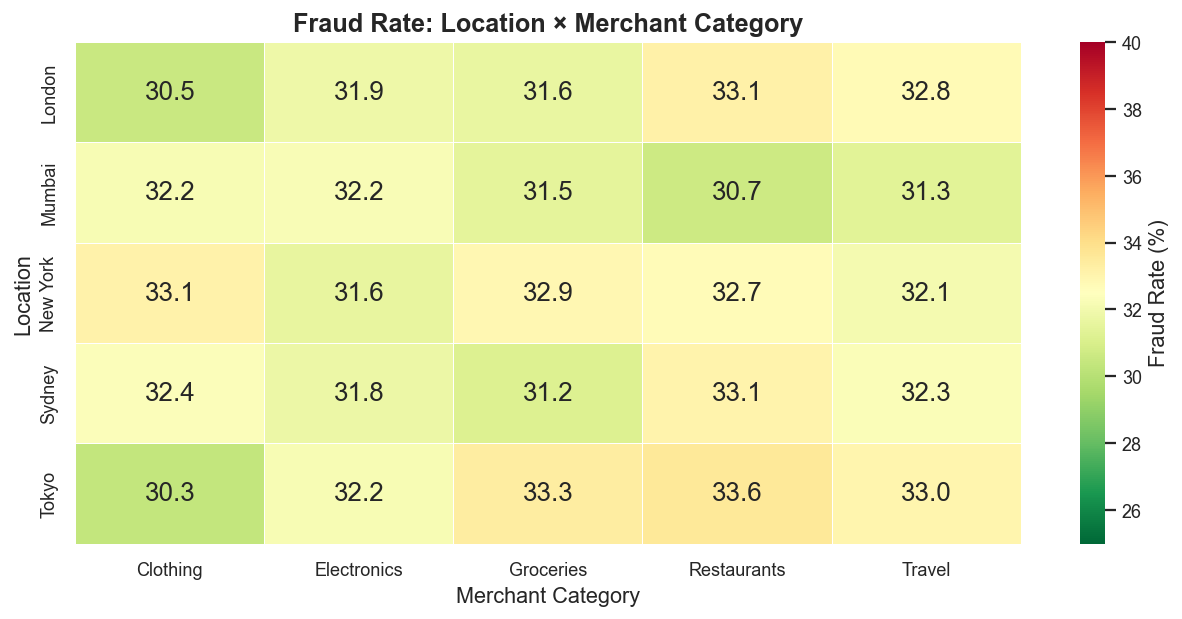

In [15]:
# ── Location x Merchant_Category fraud-rate heatmap ──────────────────────
pivot2 = df.groupby(['Location','Merchant_Category'])['Fraud_Label'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot2, ax=ax, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Fraud Rate (%)'},
            vmin=25, vmax=40)
ax.set_title('Fraud Rate: Location × Merchant Category', fontweight='bold')
ax.set_xlabel('Merchant Category')
ax.set_ylabel('Location')
plt.tight_layout()
plt.show()

---
# Part 2 — Graph Data EDA

## 2.1 Load Heterogeneous Graph

In [16]:
try:
    graph = torch.load(GRAPH_PT, map_location='cpu', weights_only=False)
except TypeError:
    graph = torch.load(GRAPH_PT, map_location='cpu')

print('=' * 60)
print('HETEROGENEOUS GRAPH SUMMARY')
print('=' * 60)
print(f'\nNode types ({len(graph.node_types)}):')
for nt in graph.node_types:
    x = graph[nt].x
    print(f'  {nt:25s}  nodes={x.shape[0]:>6,}  features={x.shape[1]}')

print(f'\nEdge types ({len(graph.edge_types)}):')
for et in graph.edge_types:
    ei = graph[et].edge_index
    print(f'  {str(et):50s}  edges={ei.shape[1]:>8,}')

y = graph['transaction'].y
print(f'\nTransaction labels: {(y==0).sum().item():,} legit / {(y==1).sum().item():,} fraud  (fraud rate: {y.float().mean():.1%})')

train_mask = graph['transaction'].train_mask
val_mask   = graph['transaction'].val_mask
test_mask  = graph['transaction'].test_mask
print(f'\nSplit sizes: train={train_mask.sum().item():,}  val={val_mask.sum().item():,}  test={test_mask.sum().item():,}')

HETEROGENEOUS GRAPH SUMMARY

Node types (4):
  transaction                nodes=50,000  features=28
  user                       nodes= 8,963  features=5
  location                   nodes=     5  features=3
  merchant_category          nodes=     5  features=3

Edge types (6):
  ('user', 'performs', 'transaction')                 edges=  50,000
  ('transaction', 'performed_by', 'user')             edges=  50,000
  ('transaction', 'at', 'location')                   edges=  50,000
  ('location', 'is_site_of', 'transaction')           edges=  50,000
  ('transaction', 'belongs_to', 'merchant_category')  edges=  50,000
  ('merchant_category', 'contains', 'transaction')    edges=  50,000

Transaction labels: 33,933 legit / 16,067 fraud  (fraud rate: 32.1%)

Split sizes: train=35,000  val=7,500  test=7,500


## 2.2 Graph Structure Summary Table

In [17]:
node_rows = []
for nt in graph.node_types:
    x = graph[nt].x
    node_rows.append({'Entity': nt, 'Nodes': x.shape[0], 'Feature Dim': x.shape[1], 'Type': 'Node'})
node_df = pd.DataFrame(node_rows)

edge_rows = []
for et in graph.edge_types:
    src, rel, dst = et
    cnt = graph[et].edge_index.shape[1]
    edge_rows.append({'Source': src, 'Relation': rel, 'Target': dst, 'Edges': cnt})
edge_df = pd.DataFrame(edge_rows)

print('── Node Types ──')
display(node_df.style.background_gradient(subset=['Nodes'], cmap='Blues'))
print('\n── Edge Types ──')
display(edge_df.style.background_gradient(subset=['Edges'], cmap='Purples'))

── Node Types ──


,Entity,Nodes,Feature Dim,Type
0,transaction,50000,28,Node
1,user,8963,5,Node
2,location,5,3,Node
3,merchant_category,5,3,Node



── Edge Types ──


,Source,Relation,Target,Edges
0,user,performs,transaction,50000
1,transaction,performed_by,user,50000
2,transaction,at,location,50000
3,location,is_site_of,transaction,50000
4,transaction,belongs_to,merchant_category,50000
5,merchant_category,contains,transaction,50000


## 2.3 Meta-Graph (Schema) Visualization

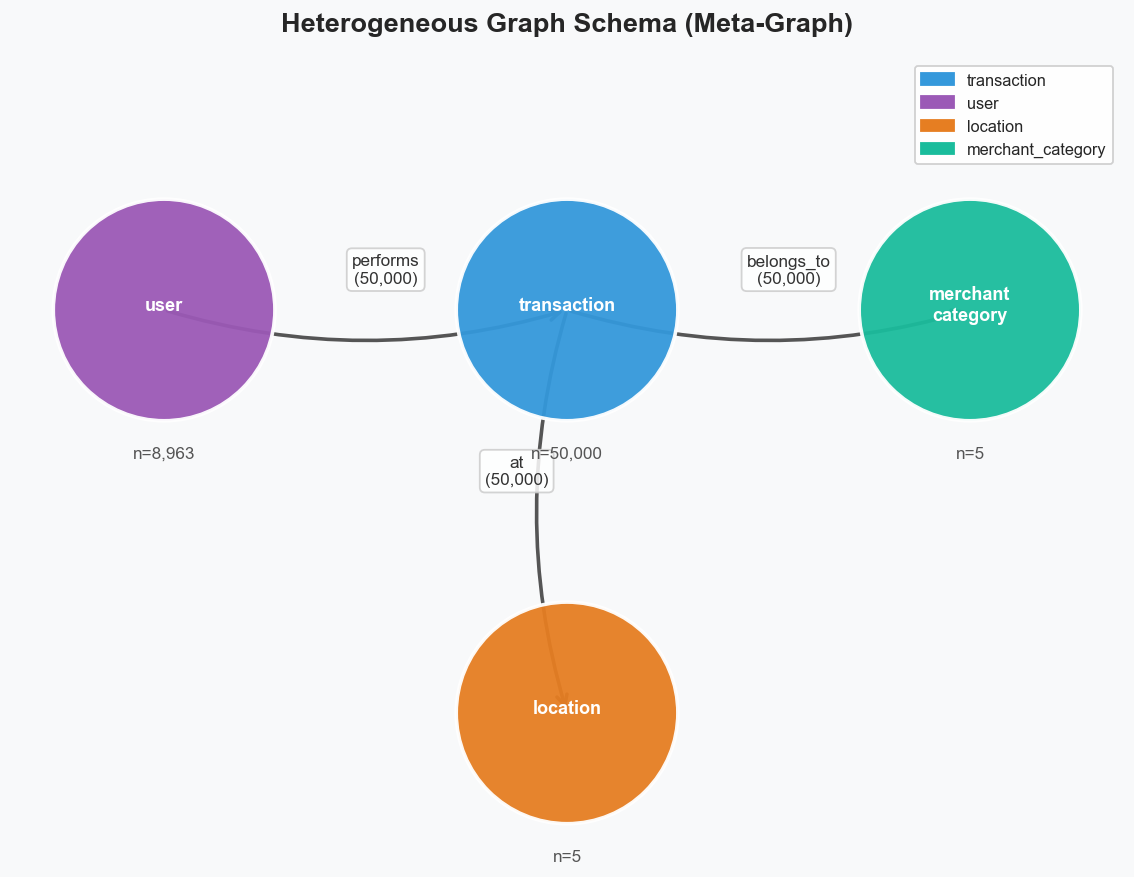

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

# Manual positions for clarity
node_pos = {
    'transaction':       (0.5, 0.5),
    'user':              (0.1, 0.5),
    'location':          (0.5, 0.1),
    'merchant_category': (0.9, 0.5),
}
node_colors = {
    'transaction':       '#3498DB',
    'user':              '#9B59B6',
    'location':          '#E67E22',
    'merchant_category': '#1ABC9C',
}
node_counts = {nt: graph[nt].x.shape[0] for nt in graph.node_types}

# Draw edges (only forward direction)
forward_edges = [
    ('user', 'performs', 'transaction'),
    ('transaction', 'at', 'location'),
    ('transaction', 'belongs_to', 'merchant_category'),
]
for et in forward_edges:
    src, rel, dst = et
    x0, y0 = node_pos[src]
    x1, y1 = node_pos[dst]
    cnt = graph[et].edge_index.shape[1]
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='#555', lw=2.0,
                                connectionstyle='arc3,rad=0.15'))
    mx, my = (x0 + x1) / 2, (y0 + y1) / 2
    # Offset label slightly
    off_x = -0.07 if src == 'transaction' and dst == 'location' else 0.0
    ax.text(mx + off_x + 0.02, my + 0.04, f'{rel}\n({cnt:,})',
            ha='center', va='center', fontsize=9.5,
            color='#333',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#ccc', alpha=0.85))

# Draw nodes
for nt, (x, y_) in node_pos.items():
    circle = plt.Circle((x, y_), 0.11, color=node_colors[nt],
                         zorder=5, alpha=0.95, linewidth=2, ec='white')
    ax.add_patch(circle)
    label = nt.replace('_', '\n')
    ax.text(x, y_ + 0.005, label,
            ha='center', va='center', fontsize=10, fontweight='bold',
            color='white', zorder=6)
    ax.text(x, y_ - 0.135, f'n={node_counts[nt]:,}',
            ha='center', va='top', fontsize=9.5, color='#555')

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 0.75)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Heterogeneous Graph Schema (Meta-Graph)', fontsize=15, fontweight='bold', pad=15)

# Legend
legend_patches = [mpatches.Patch(color=c, label=nt) for nt, c in node_colors.items()]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

## 2.4 User Node — Degree Distribution

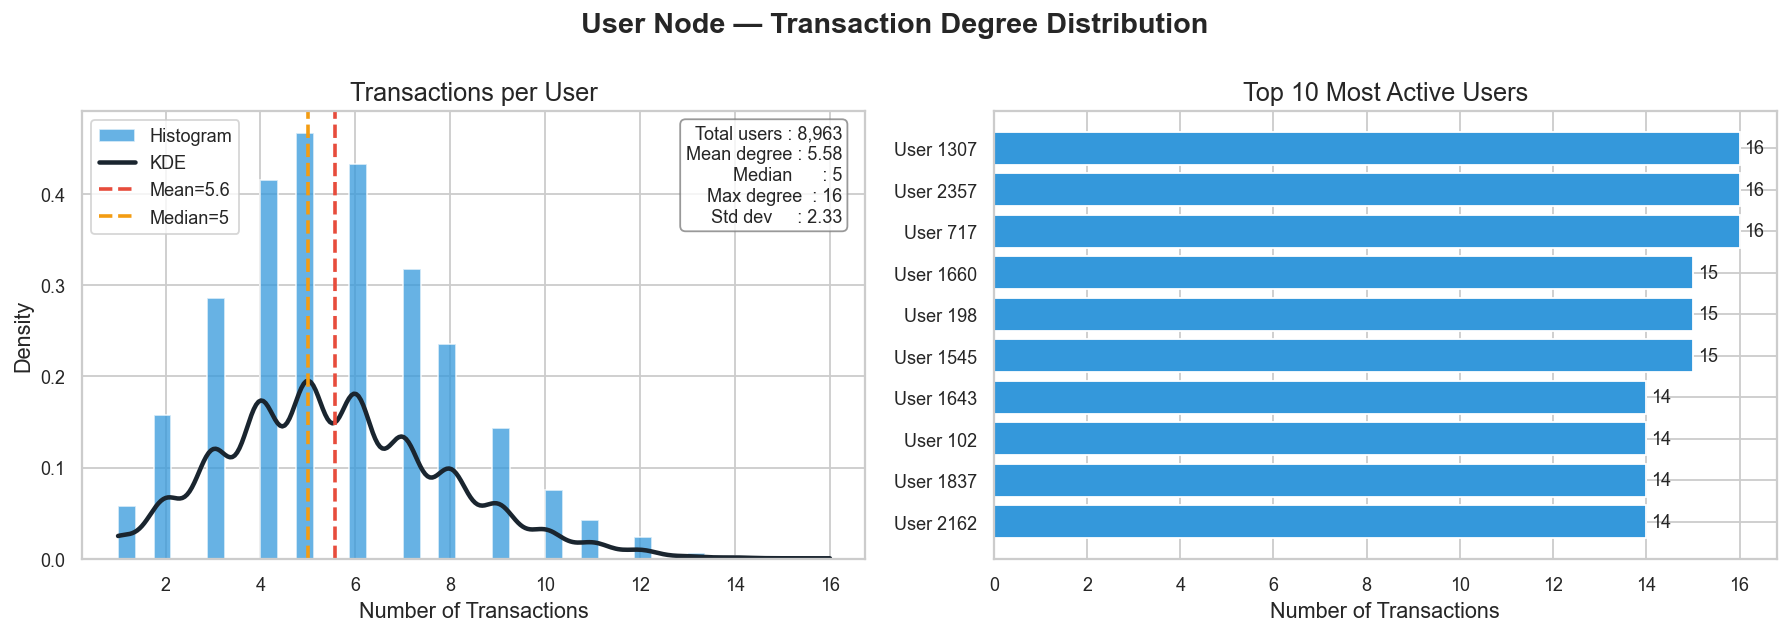

In [19]:
# User → transaction degree (how many transactions per user)
ei = graph[('user', 'performs', 'transaction')].edge_index
n_users = graph['user'].x.shape[0]

user_degree = torch.bincount(ei[0], minlength=n_users).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('User Node — Transaction Degree Distribution', fontweight='bold')

# Histogram + KDE
axes[0].hist(user_degree, bins=40, color=ACCENT_COLOR, edgecolor='white',
             density=True, alpha=0.75, label='Histogram')
kde_x = np.linspace(user_degree.min(), user_degree.max(), 300)
kde = stats.gaussian_kde(user_degree)
axes[0].plot(kde_x, kde(kde_x), color='#1A252F', linewidth=2.5, label='KDE')
axes[0].axvline(user_degree.mean(), color=FRAUD_COLOR, linestyle='--',
               linewidth=2, label=f'Mean={user_degree.mean():.1f}')
axes[0].axvline(np.median(user_degree), color='#F39C12', linestyle='--',
               linewidth=2, label=f'Median={np.median(user_degree):.0f}')
axes[0].set_title('Transactions per User')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Density')
axes[0].legend()

stats_text = (f'Total users : {n_users:,}\n'
              f'Mean degree : {user_degree.mean():.2f}\n'
              f'Median      : {np.median(user_degree):.0f}\n'
              f'Max degree  : {user_degree.max()}\n'
              f'Std dev     : {user_degree.std():.2f}')
axes[0].text(0.97, 0.97, stats_text, transform=axes[0].transAxes,
             va='top', ha='right', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='grey', alpha=0.8))

# Top-10 most active users
top_idx = np.argsort(user_degree)[-10:][::-1]
top_deg = user_degree[top_idx]
axes[1].barh([f'User {i}' for i in top_idx], top_deg,
             color=ACCENT_COLOR, edgecolor='white')
for i, v in enumerate(top_deg):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=10)
axes[1].set_title('Top 10 Most Active Users')
axes[1].set_xlabel('Number of Transactions')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 2.5 Transaction Feature Space — PCA & t-SNE

Running t-SNE (may take ~30 s)...


  File "C:\Users\abdia\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\abdia\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\abdia\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\abdia\anaconda3\Lib\subprocess.

Done.


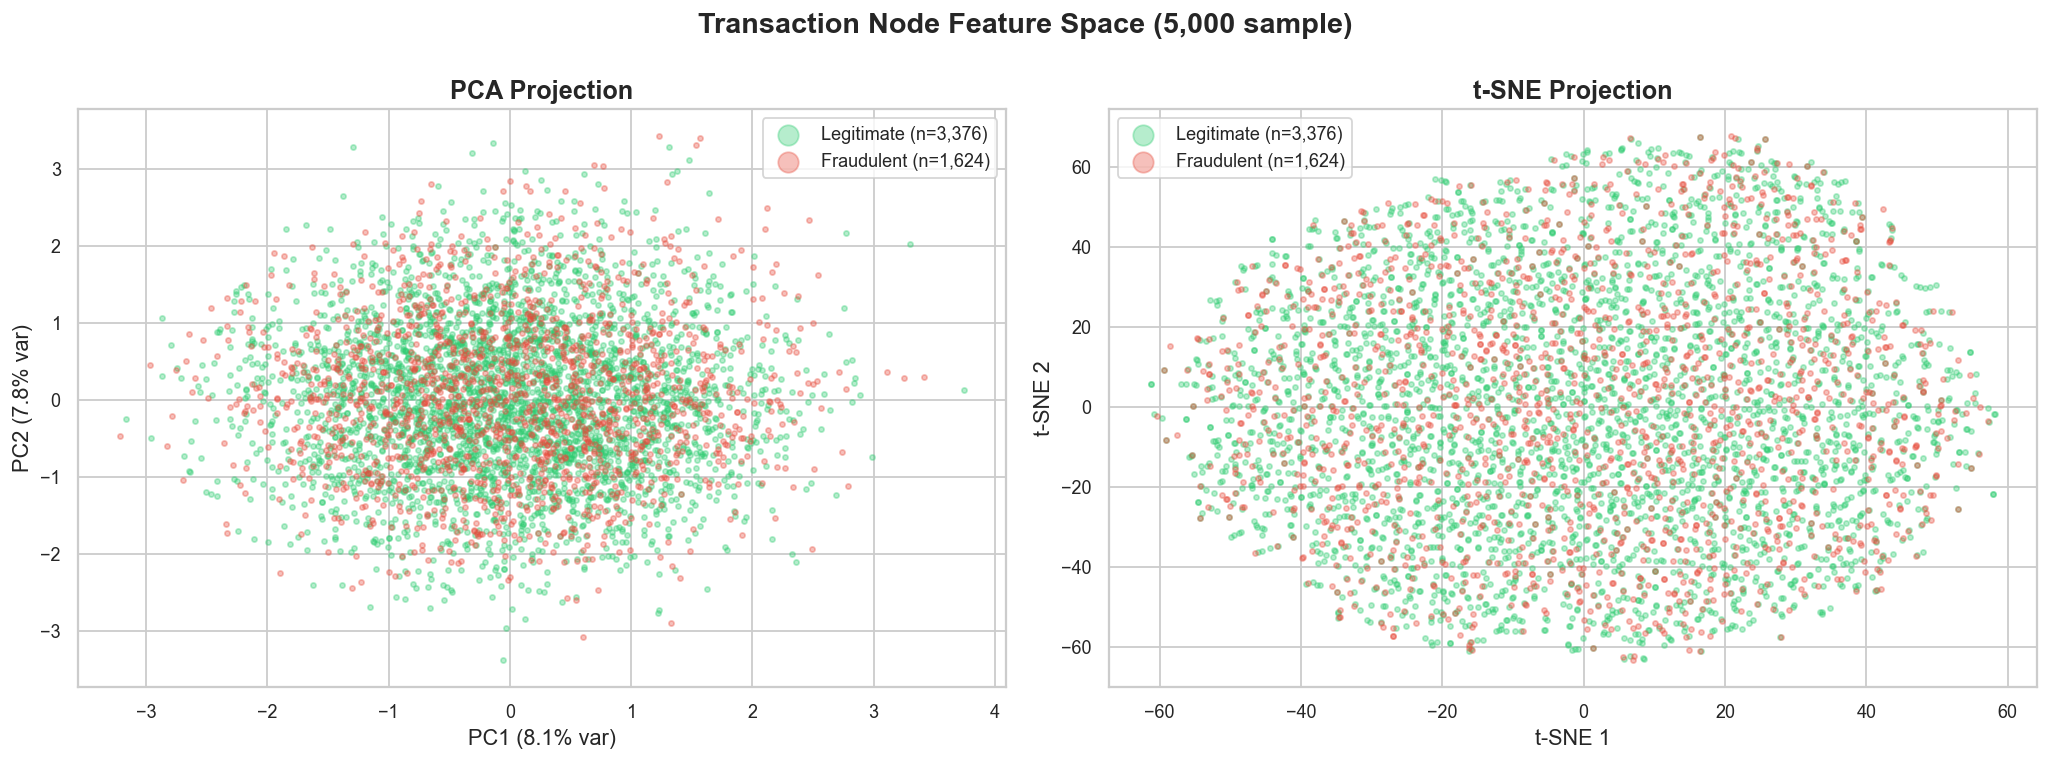

In [20]:
# Sample 5,000 transactions for visualisation
txn_feats = graph['transaction'].x.numpy()
txn_labels = graph['transaction'].y.numpy()

np.random.seed(42)
idx = np.random.choice(len(txn_labels), size=5000, replace=False)
X_sample = txn_feats[idx]
y_sample = txn_labels[idx]

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)
var_exp = pca.explained_variance_ratio_ * 100

# t-SNE
print('Running t-SNE (may take ~30 s)...')
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,
            random_state=42, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_sample)
print('Done.')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Transaction Node Feature Space (5,000 sample)', fontweight='bold')

for ax, X_2d, title, xtitle, ytitle in [
    (axes[0], X_pca,  'PCA Projection',
     f'PC1 ({var_exp[0]:.1f}% var)', f'PC2 ({var_exp[1]:.1f}% var)'),
    (axes[1], X_tsne, 't-SNE Projection', 't-SNE 1', 't-SNE 2'),
]:
    for fraud_val, color, lname in [(0, LEGIT_COLOR, 'Legitimate'), (1, FRAUD_COLOR, 'Fraudulent')]:
        mask = y_sample == fraud_val
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, alpha=0.35, s=8, label=f'{lname} (n={mask.sum():,})')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xtitle)
    ax.set_ylabel(ytitle)
    ax.legend(markerscale=4, fontsize=10)

plt.tight_layout()
plt.show()

## 2.6 User Node Feature Analysis

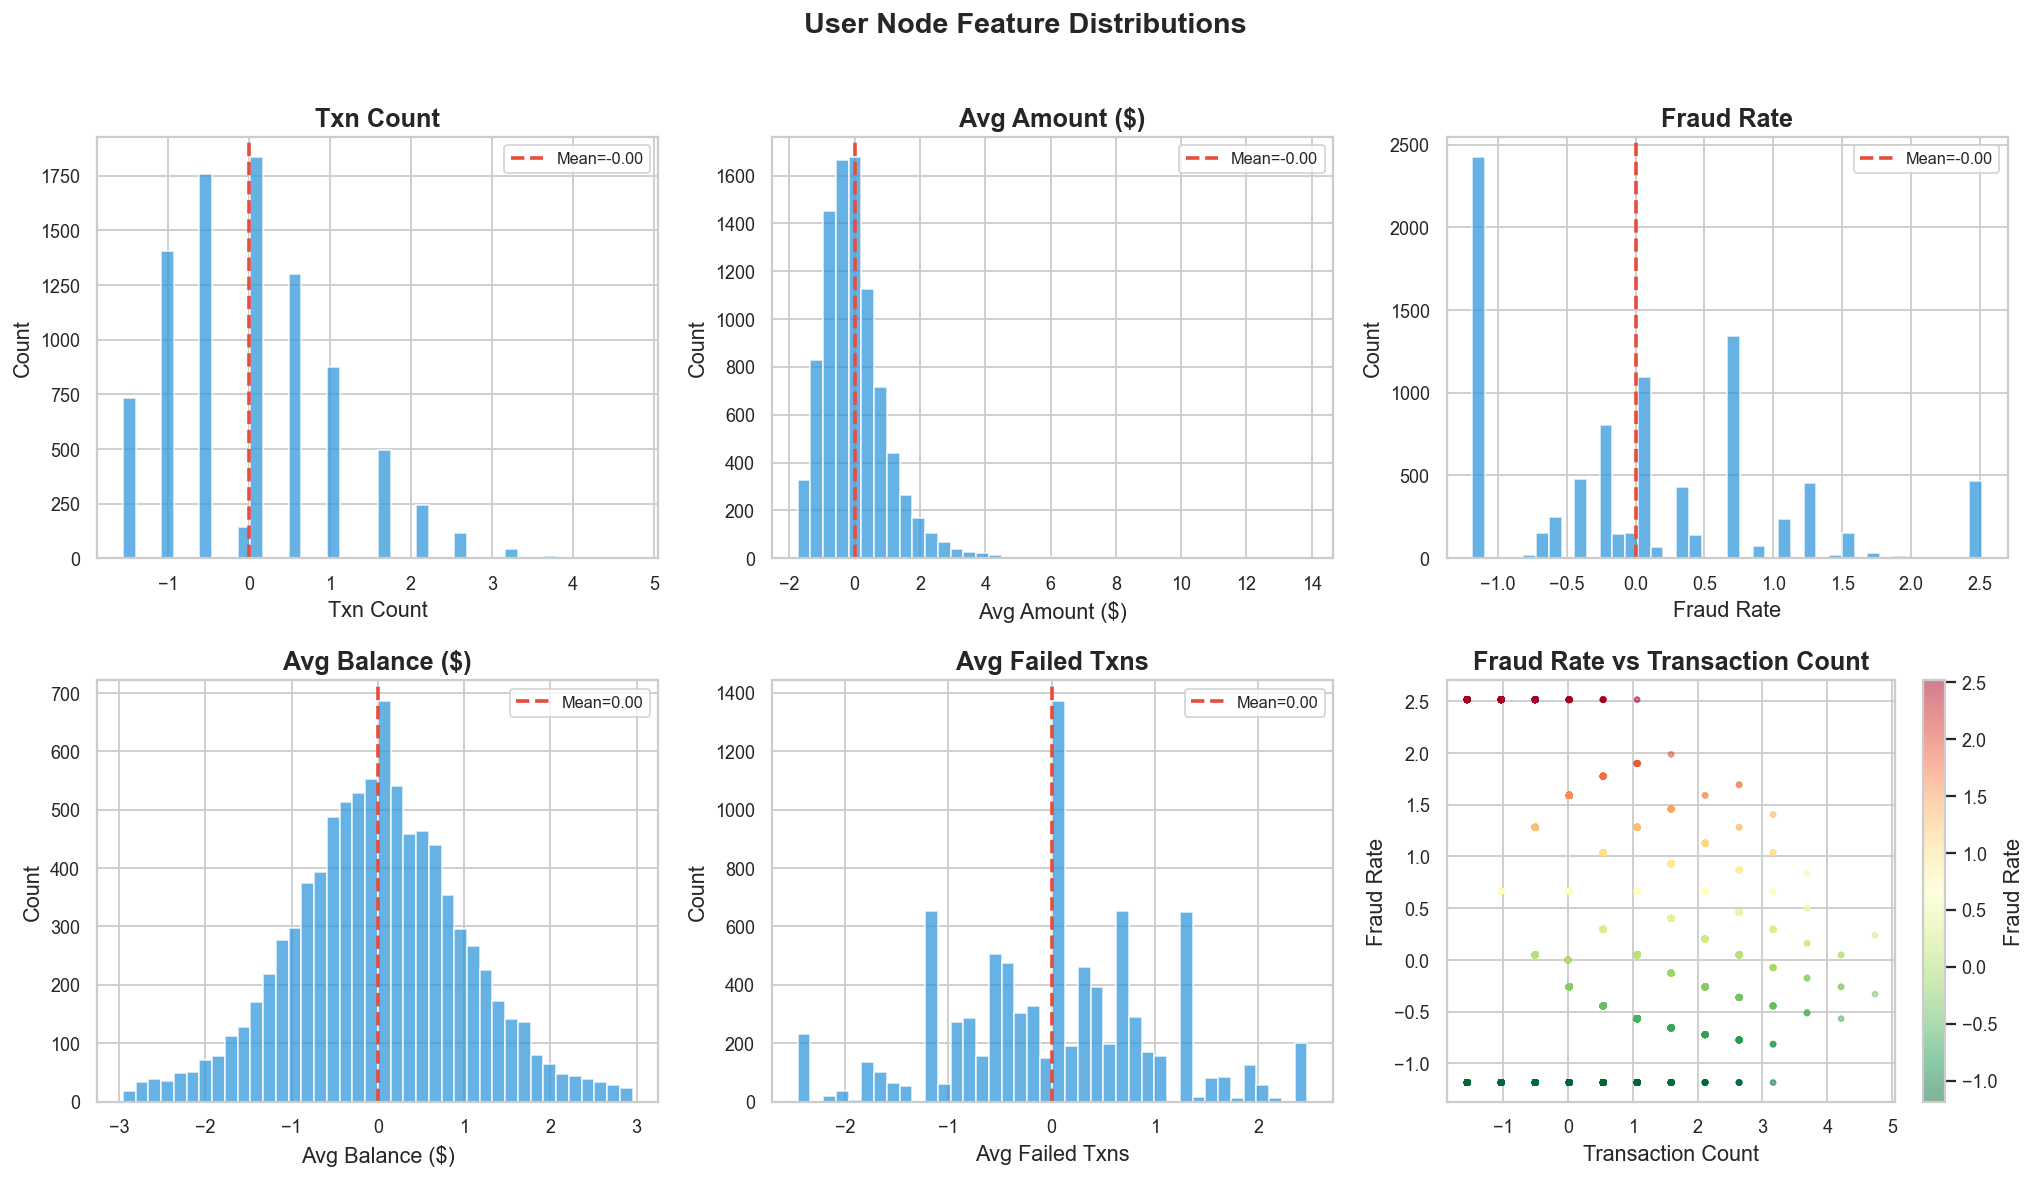


High-risk users (fraud_rate > 0.7): 1,448 out of 8,963 (16.2%)


,Txn Count,Avg Amount ($),Fraud Rate,Avg Balance ($),Avg Failed Txns
count,1448.000,1448.000,1448.000,1448.000,1448.000
mean,-0.185,0.026,1.673,0.001,0.844
std,0.994,1.098,0.610,1.068,1.103
min,-1.557,-1.751,0.833,-2.949,-2.462
25%,-1.033,-0.689,1.282,-0.673,0.008
50%,-0.508,-0.150,1.282,0.007,0.831
75%,0.541,0.477,2.515,0.684,1.654
max,3.688,9.535,2.515,2.942,2.477


In [21]:
user_feats = graph['user'].x.numpy()
USER_FEAT_NAMES = ['Txn Count', 'Avg Amount ($)', 'Fraud Rate', 'Avg Balance ($)', 'Avg Failed Txns']
user_df = pd.DataFrame(user_feats, columns=USER_FEAT_NAMES)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('User Node Feature Distributions', fontweight='bold', y=1.01)

for ax, col in zip(axes.flat[:5], USER_FEAT_NAMES):
    data = user_df[col].dropna()
    ax.hist(data, bins=40, color=ACCENT_COLOR, edgecolor='white', alpha=0.75)
    ax.axvline(data.mean(), color=FRAUD_COLOR, linestyle='--', linewidth=2,
               label=f'Mean={data.mean():.2f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

# Fraud rate vs txn count scatter
sc = axes.flat[5].scatter(user_df['Txn Count'], user_df['Fraud Rate'],
                           c=user_df['Fraud Rate'],
                           cmap='RdYlGn_r', alpha=0.5, s=8)
plt.colorbar(sc, ax=axes.flat[5], label='Fraud Rate')
axes.flat[5].set_title('Fraud Rate vs Transaction Count', fontweight='bold')
axes.flat[5].set_xlabel('Transaction Count')
axes.flat[5].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

# High-risk users
high_risk = user_df[user_df['Fraud Rate'] > 0.7]
print(f'\nHigh-risk users (fraud_rate > 0.7): {len(high_risk):,} out of {len(user_df):,} '
      f'({len(high_risk)/len(user_df):.1%})')
high_risk.describe().round(3)

## 2.7 Location & Merchant Category Analysis

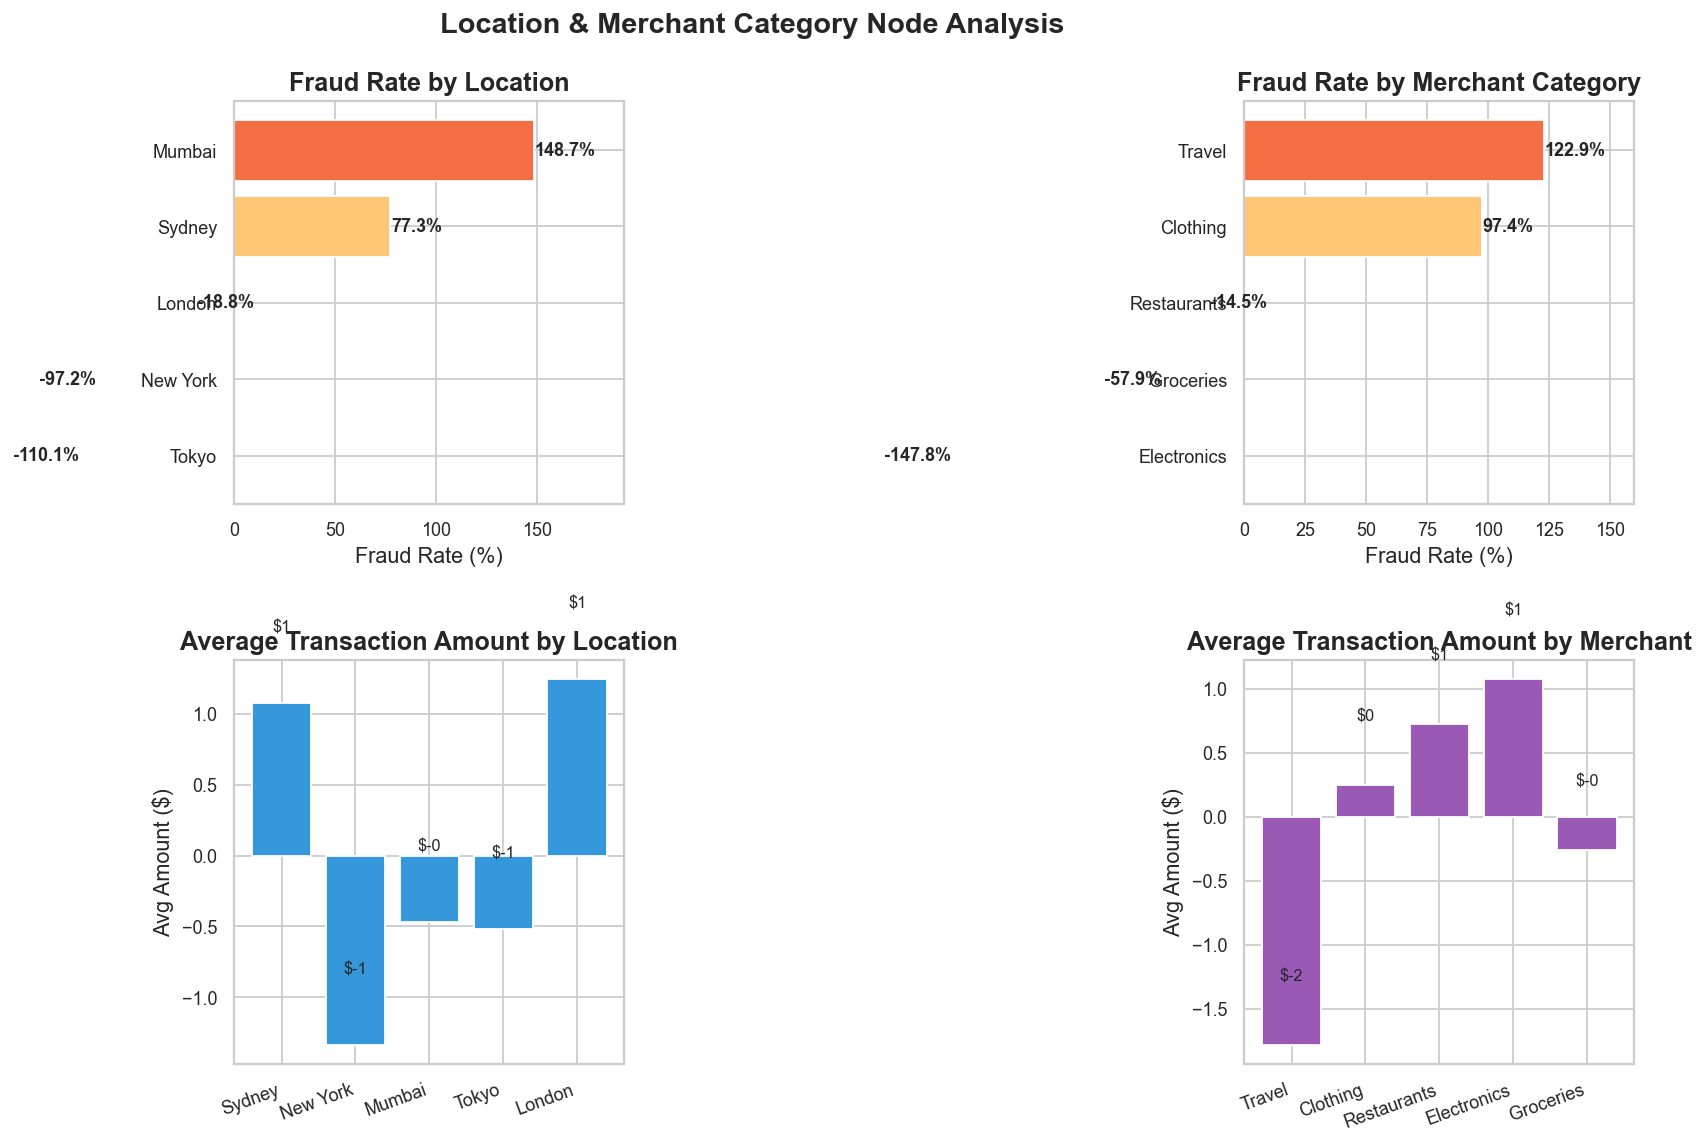

In [22]:
# Entity node features
loc_feats  = graph['location'].x.numpy()
merc_feats = graph['merchant_category'].x.numpy()

LOCATIONS   = ['Sydney', 'New York', 'Mumbai', 'Tokyo', 'London']
MERCHANTS   = ['Travel', 'Clothing', 'Restaurants', 'Electronics', 'Groceries']
ENTITY_FEAT = ['Txn Count', 'Avg Amount ($)', 'Fraud Rate']

# Adjust list lengths to actual node count
LOCATIONS = LOCATIONS[:loc_feats.shape[0]]
MERCHANTS = MERCHANTS[:merc_feats.shape[0]]

loc_df  = pd.DataFrame(loc_feats,  columns=ENTITY_FEAT, index=LOCATIONS)
merc_df = pd.DataFrame(merc_feats, columns=ENTITY_FEAT, index=MERCHANTS)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Location & Merchant Category Node Analysis', fontweight='bold')

# Location fraud rate
fr_loc = loc_df['Fraud Rate'].sort_values()
colors_loc = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(fr_loc)))
bars = axes[0,0].barh(fr_loc.index, fr_loc.values * 100,
                       color=colors_loc, edgecolor='white')
for bar, v in zip(bars, fr_loc.values * 100):
    axes[0,0].text(v + 0.3, bar.get_y() + bar.get_height()/2,
                   f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[0,0].set_title('Fraud Rate by Location', fontweight='bold')
axes[0,0].set_xlabel('Fraud Rate (%)')
axes[0,0].set_xlim(0, fr_loc.max() * 130)

# Merchant fraud rate
fr_merc = merc_df['Fraud Rate'].sort_values()
colors_merc = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(fr_merc)))
bars = axes[0,1].barh(fr_merc.index, fr_merc.values * 100,
                       color=colors_merc, edgecolor='white')
for bar, v in zip(bars, fr_merc.values * 100):
    axes[0,1].text(v + 0.3, bar.get_y() + bar.get_height()/2,
                   f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[0,1].set_title('Fraud Rate by Merchant Category', fontweight='bold')
axes[0,1].set_xlabel('Fraud Rate (%)')
axes[0,1].set_xlim(0, fr_merc.max() * 130)

# Location avg amount
x_pos = np.arange(len(LOCATIONS))
axes[1,0].bar(x_pos, loc_df['Avg Amount ($)'],
              color=ACCENT_COLOR, edgecolor='white')
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(LOCATIONS, rotation=20, ha='right')
axes[1,0].set_title('Average Transaction Amount by Location', fontweight='bold')
axes[1,0].set_ylabel('Avg Amount ($)')
for i, v in enumerate(loc_df['Avg Amount ($)']):
    axes[1,0].text(i, v + 0.5, f'${v:.0f}', ha='center', fontsize=9)

# Merchant avg amount
x_pos2 = np.arange(len(MERCHANTS))
axes[1,1].bar(x_pos2, merc_df['Avg Amount ($)'],
              color='#9B59B6', edgecolor='white')
axes[1,1].set_xticks(x_pos2)
axes[1,1].set_xticklabels(MERCHANTS, rotation=20, ha='right')
axes[1,1].set_title('Average Transaction Amount by Merchant', fontweight='bold')
axes[1,1].set_ylabel('Avg Amount ($)')
for i, v in enumerate(merc_df['Avg Amount ($)']):
    axes[1,1].text(i, v + 0.5, f'${v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 2.8 Graph Connectivity Overview

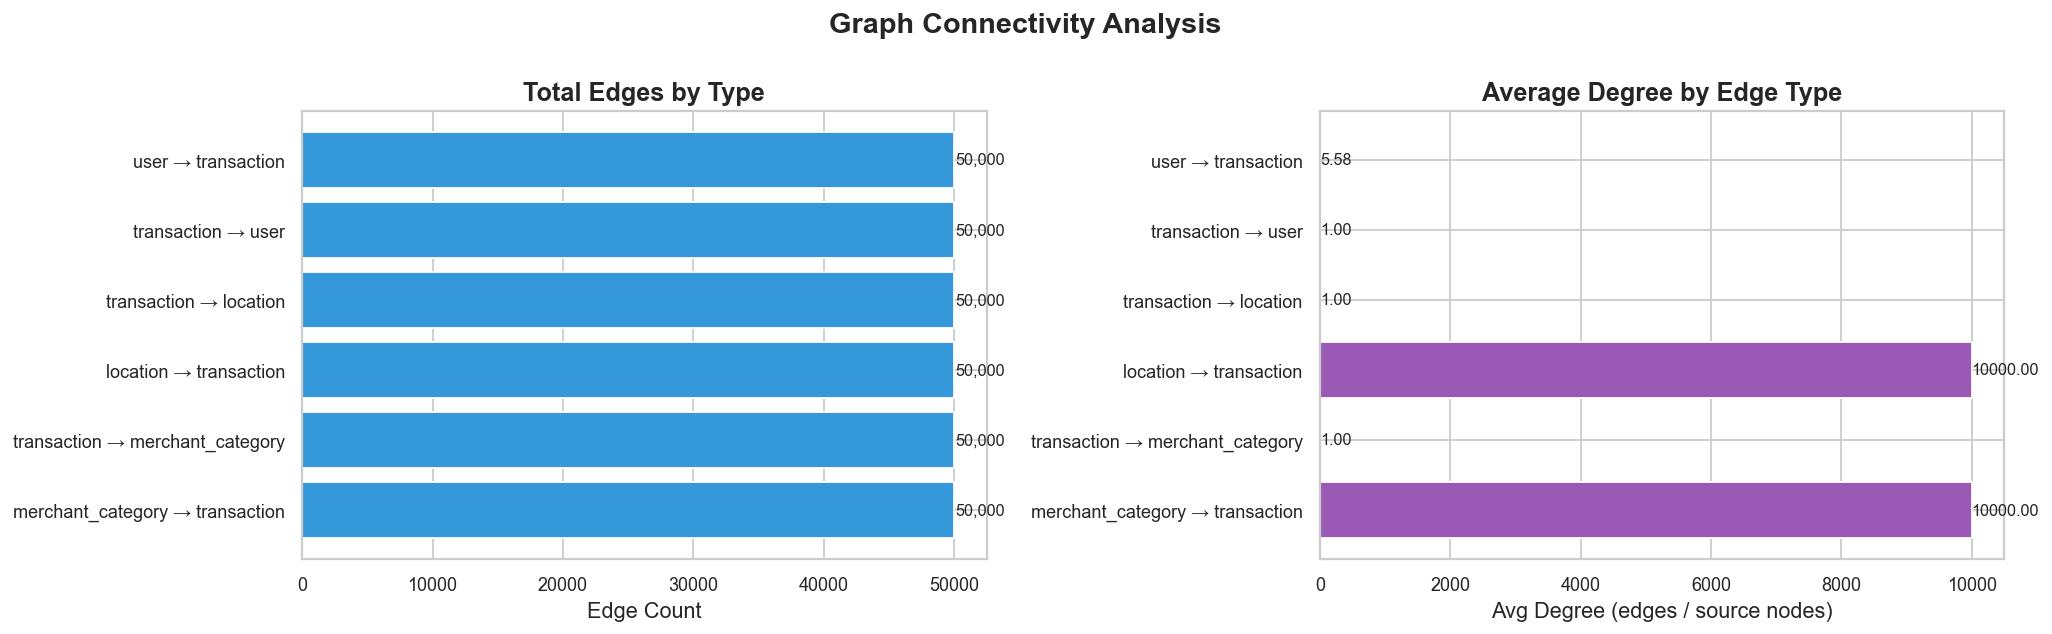

,Edge Type,Relation,Total Edges,Src Nodes,Avg Degree
0,user → transaction,performs,50000,8963,5.580000
1,transaction → user,performed_by,50000,50000,1.000000
2,transaction → location,at,50000,50000,1.000000
3,location → transaction,is_site_of,50000,5,10000.000000
4,transaction → merchant_category,belongs_to,50000,50000,1.000000
5,merchant_category → transaction,contains,50000,5,10000.000000


In [23]:
conn_rows = []
for et in graph.edge_types:
    src, rel, dst = et
    ei = graph[et].edge_index
    n_src = graph[src].x.shape[0]
    avg_deg = ei.shape[1] / n_src
    conn_rows.append({
        'Edge Type': f'{src} → {dst}',
        'Relation': rel,
        'Total Edges': ei.shape[1],
        'Src Nodes': n_src,
        'Avg Degree': round(avg_deg, 2)
    })
conn_df = pd.DataFrame(conn_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Graph Connectivity Analysis', fontweight='bold')

# Bar: total edges per edge type
et_labels = [f"{r['Edge Type']}" for _, r in conn_df.iterrows()]
axes[0].barh(et_labels, conn_df['Total Edges'],
             color=ACCENT_COLOR, edgecolor='white')
for i, v in enumerate(conn_df['Total Edges']):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)
axes[0].set_title('Total Edges by Type', fontweight='bold')
axes[0].set_xlabel('Edge Count')
axes[0].invert_yaxis()

# Bar: avg degree
axes[1].barh(et_labels, conn_df['Avg Degree'],
             color='#9B59B6', edgecolor='white')
for i, v in enumerate(conn_df['Avg Degree']):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
axes[1].set_title('Average Degree by Edge Type', fontweight='bold')
axes[1].set_xlabel('Avg Degree (edges / source nodes)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

display(conn_df.style.background_gradient(subset=['Total Edges','Avg Degree'], cmap='Blues'))

## 2.9 Train / Val / Test Split Analysis

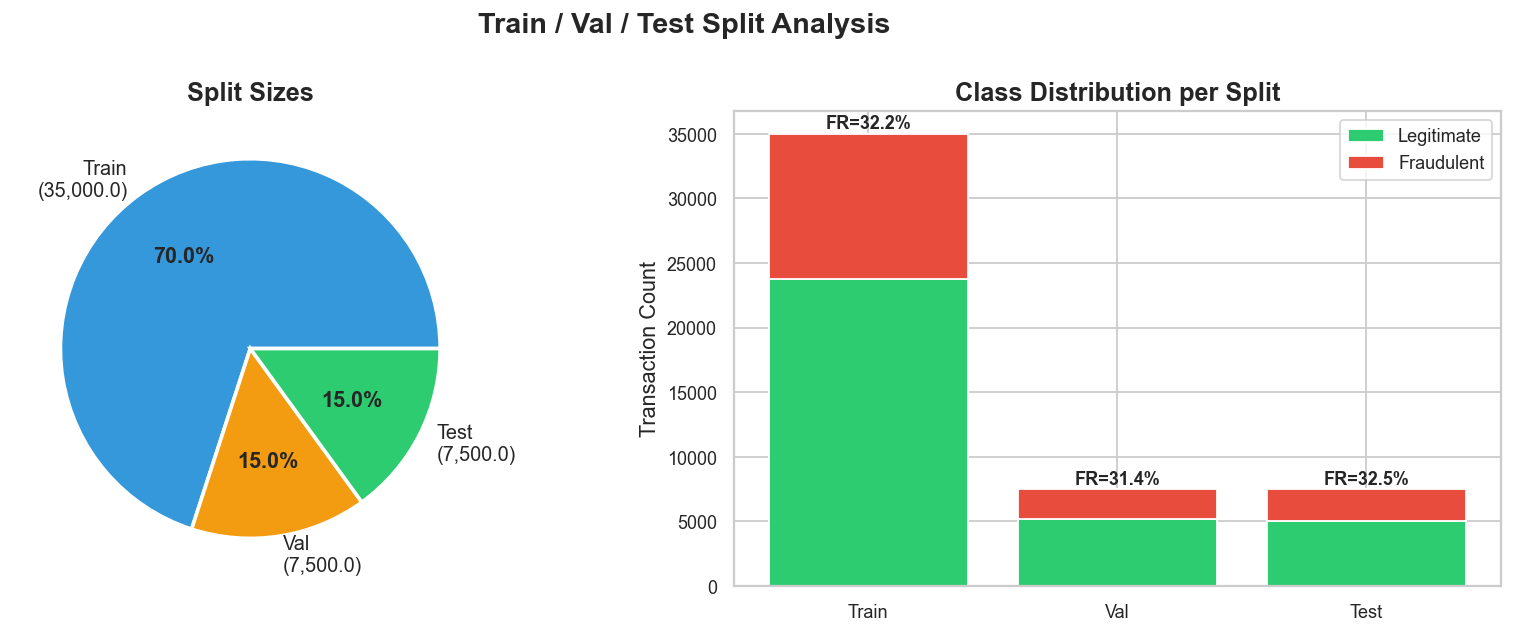

,Total,Legit,Fraud,Fraud Rate
Train,"35,000.0","23,731.0","11,269.0",32.2%
Val,"7,500.0","5,142.0","2,358.0",31.4%
Test,"7,500.0","5,060.0","2,440.0",32.5%


In [24]:
masks = {'Train': train_mask, 'Val': val_mask, 'Test': test_mask}
split_stats = {}
for name, mask in masks.items():
    labels_split = y[mask]
    split_stats[name] = {
        'Total': mask.sum().item(),
        'Legit': (labels_split == 0).sum().item(),
        'Fraud': (labels_split == 1).sum().item(),
        'Fraud Rate': labels_split.float().mean().item(),
    }
split_df = pd.DataFrame(split_stats).T

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Train / Val / Test Split Analysis', fontweight='bold')

# Pie: split sizes
totals = split_df['Total'].values
split_colors = ['#3498DB', '#F39C12', '#2ECC71']
wedges, texts, autotexts = axes[0].pie(
    totals,
    labels=[f"{n}\n({t:,})" for n, t in zip(split_df.index, totals)],
    autopct='%1.1f%%',
    colors=split_colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11})
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[0].set_title('Split Sizes', fontweight='bold')

# Stacked bar: legit vs fraud per split
x = np.arange(len(split_df))
legit_vals = split_df['Legit'].values
fraud_vals = split_df['Fraud'].values
axes[1].bar(split_df.index, legit_vals, color=LEGIT_COLOR,
            label='Legitimate', edgecolor='white')
axes[1].bar(split_df.index, fraud_vals, bottom=legit_vals,
            color=FRAUD_COLOR, label='Fraudulent', edgecolor='white')
for i, (l, f, fr) in enumerate(zip(legit_vals, fraud_vals,
                                    split_df['Fraud Rate'].values)):
    axes[1].text(i, l + f + 100, f'FR={fr:.1%}', ha='center',
                va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Class Distribution per Split', fontweight='bold')
axes[1].set_ylabel('Transaction Count')
axes[1].legend()

plt.tight_layout()
plt.show()

display(split_df.style.format({'Total': '{:,}', 'Legit': '{:,}',
                                'Fraud': '{:,}', 'Fraud Rate': '{:.1%}'})
        .background_gradient(subset=['Fraud Rate'], cmap='RdYlGn_r'))

## 2.10 Transaction Feature Importance (Variance per Feature)

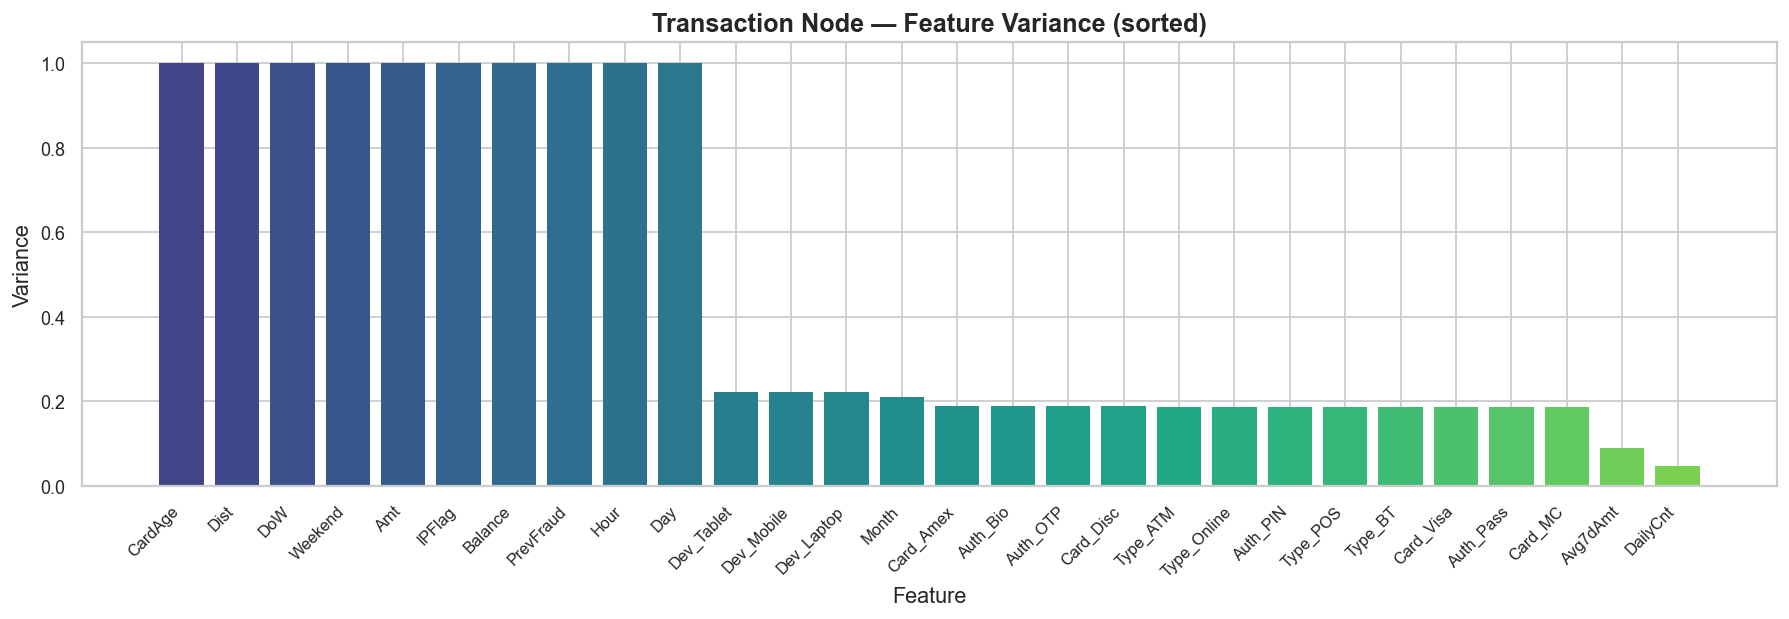

In [25]:
txn_feats_all = graph['transaction'].x.numpy()
n_feats = txn_feats_all.shape[1]

variances = txn_feats_all.var(axis=0)
feat_labels_short = [
    'Amt','Balance','DailyCnt','Avg7dAmt','CardAge','Dist',
    'Hour','Day','Month','DoW',
    'IPFlag','PrevFraud','Weekend',
    'Type_POS','Type_BT','Type_Online','Type_ATM',
    'Dev_Laptop','Dev_Mobile','Dev_Tablet',
    'Card_Visa','Card_MC','Card_Amex','Card_Disc',
    'Auth_Bio','Auth_Pass','Auth_OTP','Auth_PIN'
]
# Pad if shapes differ
while len(feat_labels_short) < n_feats:
    feat_labels_short.append(f'f{len(feat_labels_short)}')
feat_labels_short = feat_labels_short[:n_feats]

sort_idx = np.argsort(variances)[::-1]
fig, ax = plt.subplots(figsize=(14, 5))
colors_var = plt.cm.viridis(np.linspace(0.2, 0.8, n_feats))
ax.bar(range(n_feats), variances[sort_idx],
       color=colors_var, edgecolor='none')
ax.set_xticks(range(n_feats))
ax.set_xticklabels([feat_labels_short[i] for i in sort_idx],
                   rotation=45, ha='right', fontsize=9)
ax.set_title('Transaction Node — Feature Variance (sorted)', fontweight='bold')
ax.set_ylabel('Variance')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.show()

---
# Part 3 — Key Findings Summary

In [26]:
findings = [
    ('Dataset',       '50,000 transactions, 0 missing values, 32.1% fraud rate'),
    ('Class Balance', 'Moderately imbalanced (32% fraud) — less severe than typical fraud datasets (<1%)'),
    ('Top Correlates','Previous_Fraudulent_Activity and IP_Address_Flag show highest correlation with fraud'),
    ('Temporal',      'Fraud rate relatively uniform across hours and days — no strong temporal peak'),
    ('Categories',    'Fraud rate broadly similar across locations, devices, merchants (all ~30–35%)'),
    ('Graph Schema',  'Heterogeneous graph: 4 node types, 6 edge types, ~8,963 user nodes'),
    ('User Degree',   'Right-skewed: most users have few transactions; a small number are power users'),
    ('t-SNE',         'Fraud and legit transactions heavily overlap in feature space — task is non-trivial'),
    ('Splits',        'Temporal 70/15/15 split maintains consistent ~32% fraud rate across all sets'),
]

summary_df = pd.DataFrame(findings, columns=['Category', 'Finding'])
summary_df.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
}).set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('background-color', '#2C3E50'),
                                  ('color', 'white'), ('text-align', 'center')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#EAF2FB')]},
])

,Category,Finding
0,Dataset,"50,000 transactions, 0 missing values, 32.1% fraud rate"
1,Class Balance,Moderately imbalanced (32% fraud) — less severe than typical fraud datasets (<1%)
2,Top Correlates,Previous_Fraudulent_Activity and IP_Address_Flag show highest correlation with fraud
3,Temporal,Fraud rate relatively uniform across hours and days — no strong temporal peak
4,Categories,"Fraud rate broadly similar across locations, devices, merchants (all ~30–35%)"
5,Graph Schema,"Heterogeneous graph: 4 node types, 6 edge types, ~8,963 user nodes"
6,User Degree,Right-skewed: most users have few transactions; a small number are power users
7,t-SNE,Fraud and legit transactions heavily overlap in feature space — task is non-trivial
8,Splits,Temporal 70/15/15 split maintains consistent ~32% fraud rate across all sets
